# Action Factor Investigation 

These are experimental codes:      
- Briefing the data
- Tuning optimal hyperparameter
- Visualize the performance of Models
- Visualize the importance
- Visualize and summerize impacts

In [1]:
%pwd

'/mnt/d/OneDrive/MLD01_Article/MLD01e_Code'

In [2]:
%cd ..

/mnt/d/OneDrive/MLD01_Article


/home/linux/anaconda3/envs/tf/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Import PAckage

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from xgboost import XGBClassifier 

## Append Data

In [4]:
df_2016 = pd.read_parquet('Data/01_Napel2016.parquet')
df_2016['Year'] = 2016
df_2022 = pd.read_parquet('Data/01_Napel2022.parquet')
df_2022['Year'] = 2022

In [5]:
df_all = pd.concat([df_2016, df_2022], axis = 0)

In [6]:
df_all.shape

(11568, 352)

In [7]:
df_all = df_all.dropna(axis=1, how="any")

In [8]:
df_all.shape

(11568, 277)

In [9]:
df_all = df_all.set_index(['PSU', 'HHLD'])

In [10]:
df_all.columns

Index(['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age',
       'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor',
       'Edu_Master',
       ...
       'SoilWaterConservationPast25', 'VisitClimateOfficePast25',
       'FoodConsumptionHabitPast25', 'OfffarmActiPast25',
       'NonFarmEmployPast25', 'FamilyMigrationPast25', 'RiskReductionPast25',
       'RoadImprovementPast25', 'CommunityPartipationPast25', 'Year'],
      dtype='object', length=275)

In [11]:
df_all["EcoBelt"] = df_all["EcoBelt"].str.replace('Tarai', 'Terai')

In [12]:
eco_dummies = pd.get_dummies(df_all["EcoBelt"], prefix="EcoBelt").astype(int)
df_all = pd.concat([df_all, eco_dummies], axis=1)

In [13]:
prov_dummies = pd.get_dummies(df_all["Prov"], prefix="Prov").astype(int)
df_all = pd.concat([df_all, prov_dummies], axis=1)

In [14]:
df_all

EcoBelt          Prov  Rural_Dummy  Respon_Female  Respon_Age  \
PSU   HHLD                                                                   
101.0 1.0   Mountain         Koshi            1            1.0        49.0   
      2.0   Mountain         Koshi            1            0.0        55.0   
      3.0   Mountain         Koshi            1            1.0        46.0   
      4.0   Mountain         Koshi            1            0.0        78.0   
      5.0   Mountain         Koshi            1            0.0        70.0   
...              ...           ...          ...            ...         ...   
826.0 16.0     Terai  Sudurpaschim            0            0.0        47.0   
      17.0     Terai  Sudurpaschim            0            0.0        60.0   
      18.0     Terai  Sudurpaschim            0            1.0        47.0   
      19.0     Terai  Sudurpaschim            0            0.0        55.0   
      20.0     Terai  Sudurpaschim            0            0.0        45.0   

            LivingYear  Edu_UnderSLC  Edu_Certificate  Edu_Bachelor  \
PSU   HHLD                                                            
101.0 1.0         49.0             0                0             0   
      2.0         55.0             1                0             0   
      3.0         25.0             0                0             0   
      4.0         78.0             0                0             0   
      5.0         70.0             1                0             0   
...                ...           ...              ...           ...   
826.0 16.0        40.0             1                0             0   
      17.0        35.0             0                0             0   
      18.0        32.0             1                0             0   
      19.0        55.0             0                0             0   
      20.0        25.0             1                0             0   

            Edu_Master  ...  EcoBelt_Hill  EcoBelt_Mountain  EcoBelt_Terai  \
PSU   HHLD              ...                                                  
101.0 1.0            0  ...             0                 1              0   
      2.0            0  ...             0                 1              0   
      3.0            0  ...             0                 1              0   
      4.0            0  ...             0                 1              0   
      5.0            0  ...             0                 1              0   
...                ...  ...           ...               ...            ...   
826.0 16.0           0  ...             0                 0              1   
      17.0           0  ...             0                 0              1   
      18.0           0  ...             0                 0              1   
      19.0           0  ...             0                 0              1   
      20.0           0  ...             0                 0              1   

            Prov_Bagmati  Prov_Gandaki  Prov_Karnali  Prov_Koshi  \
PSU   HHLD                                                         
101.0 1.0              0             0             0           1   
      2.0              0             0             0           1   
      3.0              0             0             0           1   
      4.0              0             0             0           1   
      5.0              0             0             0           1   
...                  ...           ...           ...         ...   
826.0 16.0             0             0             0           0   
      17.0             0             0             0           0   
      18.0             0             0             0           0   
      19.0             0             0             0           0   
      20.0             0             0             0           0   

            Prov_Lumbini  Prov_Madhesh  Prov_Sudurpaschim  
PSU   HHLD                                                 
101.0 1.0              0             0                

### Revise Income Resources

In [15]:
df_all['IncomeResAgri_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 1).any(axis=1).astype(int)
df_all['IncomeResWage_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 2).any(axis=1).astype(int)
df_all['IncomeResNonAgriBusi_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 3).any(axis=1).astype(int)
df_all['IncomeResRemit_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 4).any(axis=1).astype(int)
df_all['IncomeResOthers_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 5).any(axis=1).astype(int)

In [16]:
df_all['ResidenceOwn_dummy'] = (df_all['Own_Resid'] == 1).astype(int)
df_all['ResidenceRent_dummy'] = (df_all['Own_Resid'] == 2).astype(int)
df_all['ResidenceInstitu_dummy'] = (df_all['Own_Resid'] == 3).astype(int)
df_all['ResidenceOthers_dummy'] = (df_all['Own_Resid'] == 4).astype(int)

In [17]:
df_all['ResidInfraPerman_dummy'] = (df_all['Resid_Type'] == 1).astype(int)
df_all['ResidInfraSemi_dummy'] = (df_all['Resid_Type'] == 2).astype(int)
df_all['ResidInfraKachchi_dummy'] = (df_all['Resid_Type'] == 3).astype(int)
df_all['ResidInfraOthers_dummy'] = (df_all['Resid_Type'] == 4).astype(int)

## Checking "SoilWaterConservationPast25"

### Dataset building

In [18]:
print(df_all.columns.tolist())

['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor', 'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', 'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', 'Household_memberNum', 'Own_Resid', 'Resid_Type', 'WaterS1', 'WaterS2', 'WaterS3', 'CookFuelS1', 'CookFuelS2', 'CookFuelS3', 'LightEnergy', 'Toilet', 'IncomeS1', 'IncomeS2', 'IncomeS3', 'Remittance_dummy', 'Have_AgriLand', 'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy', 'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy', 'HouseHead_AgriExpYear', 'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 'FramMechan', 'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome', 'HeardClimate_Dummy', 'ClimateChanged_Dummy', 'ClimateInf

In [19]:
df_inuse = df_all[[# target and features
                    'SoilWaterConservationPast25',
                    
                    # fearures
                    'ClimateChanged_Dummy', 'HeardClimate_Dummy', 
                   'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 
                   'Edu_Bachelor', 'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 
                   'Prov_Bagmati', 'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
                   'Prov_Gandaki', 'Prov_Karnali', # location     
                   'ResidenceOwn_dummy', 'ResidenceRent_dummy', 'ResidenceInstitu_dummy', 'ResidenceOthers_dummy',
                   'ResidInfraPerman_dummy', 'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy', 'ResidInfraOthers_dummy', # house
                    'Remittance_dummy', 
                   'Have_AgriLand', 'HouseHead_AgriExpYear',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 
                   'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 
                   'FramMechan',
                    'IncomeResAgri_dummy', 'IncomeResWage_dummy', 'IncomeResNonAgriBusi_dummy', 'IncomeResRemit_dummy',
                   'IncomeResOthers_dummy', 
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome',
                   'Year',
                   
                   # Awareness sources
                   'ClimateInfo_Radio', 'ClimateInfo_Telev', 'ClimateInfo_News ', 
                   'ClimateInfo_Aware', 'ClimateInfo_Local', 'ClimateInfo_Neigh', 
                   'ClimateInfo_Famil', 'ClimateInfo_Other',
                   
                   # Disaster experiences
                   'ExpDummyDR', 'ExpDummyFF', 'ExpDummyFS', 'ExpDummyFL', 'ExpDummyIN', 'ExpDummyWS', 
                   'ExpDummyTS', 'ExpDummyHS', 'ExpDummyHR', 'ExpDummySR', 'ExpDummySE', 'ExpDummyLS', 
                   'ExpDummySS', 'ExpDummyAV', 'ExpDummyGLOF', 'ExpDummyHW', 'ExpDummyCW', 'ExpDummyDI', 
                   'ExpDummyOT',
                   
                   # DisasterFoodShortage
                   'DisasterFoodShortage_DummyDR', 'DisasterFoodShortage_DummyFF', 'DisasterFoodShortage_DummyFS', 
                   'DisasterFoodShortage_DummyFL', 'DisasterFoodShortage_DummyIN', 'DisasterFoodShortage_DummyWS', 
                   'DisasterFoodShortage_DummyTS', 'DisasterFoodShortage_DummyHS', 'DisasterFoodShortage_DummyHR', 
                   'DisasterFoodShortage_DummySR', 'DisasterFoodShortage_DummySE', 'DisasterFoodShortage_DummyLS', 
                   'DisasterFoodShortage_DummySS', 'DisasterFoodShortage_DummyAV', 'DisasterFoodShortage_DummyGLOF', 
                   'DisasterFoodShortage_DummyHW', 'DisasterFoodShortage_DummyCW', 'DisasterFoodShortage_DummyDI', 
                   'DisasterFoodShortage_DummyOT', 'DisasterDie_DummyDR', 
                   
                   # DisasterDie
                   'DisasterDie_DummyFF', 'DisasterDie_DummyFS', 'DisasterDie_DummyFL', 'DisasterDie_DummyIN', 
                   'DisasterDie_DummyWS', 'DisasterDie_DummyTS', 'DisasterDie_DummyHS', 'DisasterDie_DummyHR', 
                   'DisasterDie_DummySR', 'DisasterDie_DummySE', 'DisasterDie_DummyLS', 'DisasterDie_DummySS', 
                   'DisasterDie_DummyAV', 'DisasterDie_DummyGLOF', 'DisasterDie_DummyHW', 'DisasterDie_DummyCW', 
                   'DisasterDie_DummyDI', 'DisasterDie_DummyOT', 
                   
                   # DisasterMoneyLoss
                   'DisasterMoneyLoss_DummyDR', 'DisasterMoneyLoss_DummyFF', 'DisasterMoneyLoss_DummyFS', 
                   'DisasterMoneyLoss_DummyFL', 'DisasterMoneyLoss_DummyIN', 'DisasterMoneyLoss_DummyWS', 
                   'DisasterMoneyLoss_DummyTS', 'DisasterMoneyLoss_DummyHS', 'DisasterMoneyLoss_DummyHR', 
                   'DisasterMoneyLoss_DummySR', 'DisasterMoneyLoss_DummySE', 'DisasterMoneyLoss_DummyLS', 
                   'DisasterMoneyLoss_DummySS', 'DisasterMoneyLoss_DummyAV', 'DisasterMoneyLoss_DummyGLOF',
                   'DisasterMoneyLoss_DummyHW', 'DisasterMoneyLoss_DummyCW', 'DisasterMoneyLoss_DummyDI', 
                   'DisasterMoneyLoss_DummyOT'
]]

In [20]:
variname_readable = {'ClimateChanged_Dummy':'Climate Change Awareness Dummy',
                     'HeardClimate_Dummy':'Heard about Climate Change Dummy', 'Respon_Female':'Female Dummy', 
                     'Respon_Age':'Age', 'LivingYear':'Years Living in Community', 'Edu_UnderSLC':'Education under Secondary Certificate Dummy', 
                     'Edu_Certificate':'Education with Secondary Certificate Dummy', 'Edu_Bachelor':'Education with Bachelor Dummy', 
                     'Edu_Master':'Education with Master Dummy',  'Edu_PhD':'Education with PhD Dummy', 
                     'Edu_Literal':'Literate Education Dummy',  'Edu_Illiterate':'Illiterate Dummy', 'Edu_year':'Education Year',
                     'Female_Ratio':'Female Ratio in Household', 'U18_Ratio':'Member Under 18 Ratio', 'A65_Ratio':'Seniors Ratio',
                     'Edu12_Ratio':"Member with 12-Year Education or above Ratio", "Literal_Ratio": "Literate Member Ratio",
                     'EcoBelt_Hill': "EcoBelt Hill Dummy", 'EcoBelt_Mountain': "EcoBelt Mountain Dummy", 'EcoBelt_Terai': "EcoBelt Terai Dummy",
                     'Prov_Bagmati': "Province Bagmati Dummy", 'Prov_Koshi': "Province Koshi Dummy", 'Prov_Lumbini': "Province Lumbibi Dummy",
                     'Prov_Madhesh': "Province Madhesh Dummy", 'Prov_Sudurpaschim': "Province Sudurpaschim Dummy", 'Prov_Gandaki': "Province Gandaki Dummy",
                     'Prov_Karnali': "Province Karnali Dummy",
                     'ResidenceOwn_dummy': "Owned Residence Ownership Dummy", 'ResidenceRent_dummy': 'Rented Residence Ownership Dummy', 
                     'ResidenceInstitu_dummy': 'Institutional Residence Ownership Dummy', 'ResidenceOthers_dummy': 'Other-type Residence Ownership Dummy',
                     'ResidInfraPerman_dummy': 'Permanent Residence Dummy', 'ResidInfraSemi_dummy': 'Semi-Permanent Residence Dummy', 
                     'ResidInfraKachchi_dummy': "Kachchi Residence Dummy", 'ResidInfraOthers_dummy': 'Other Residence Infrastructure Dummy', # house
                     'Remittance_dummy' : "Have Remittance",
                     'Have_AgriLand': "Having Agricultural Land Dummy", 'HouseHead_AgriExpYear': "Household Head Agricultural Experience",
                     'Radio_dummy': "Having Radio Dummy", 'TV_dummy': "Having TV Dummy", 'PC_dummy': "Having Computer Dummy", 'Net_dummy': "Having Internet Dummy",
                     'Phone_dummy': "Having Telephone Dummy", 'Mobile_dummy': "Having Mobile Dummy", 'Motorbike_dummy': "Having Motorbike Dummy", 
                     'Car_dummy': "Having Car Dummy", 'Bike_dummy': "Having Bike Dummy", 'OtherVehi_dummy': "Having Other Vehicle Dummy", 
                     'Refrige_dummy':"Having Refrigator Dummy",
                     'SavingMembership': "Saving Membership Dummy", 'RegularSaving': 'Having Regular Saving Dummy', 
                     'OrgMembership': 'Having Organization Membership Dummy', 'AgriSupport':'Agricultural Supporting Dummy', 
                     'Dist_Road': 'Distance to Motorable Road', 'Dist_HealthCenter': "Distance to Health Center", 
                     'Dist_SecondarySchool': "Distance to Secondary School", 'Dist_Market':"Distance to Market", 'Dist_AgriSupport': 'Distance to Agricultural Center', 
                     'FramMechan':'Farm Mechanization Dummy',
                     'IncomeResAgri_dummy': "Agricultural Income Source Dummy", 'IncomeResWage_dummy': "Wage Income Source Dummy",
                     'IncomeResNonAgriBusi_dummy': "Non-Agricultural Business Income Source Dummy", 'IncomeResRemit_dummy': "Remittance Income Dummy",
                     'IncomeResOthers_dummy': "Others Income Source Dummy", 
                     'CropIncome': "Crop Income", 'LivestockIncome': "Livestock Income", 'NonAgriIncome': "Non-agricultural Income", 
                     'BusiIncome': "Business Income", 'TotalIncome': "Total Income",
                     'Year': "Survey Year",
                                         
                    }

In [21]:
# ...existing code...
variname_readable.update({
    # Awareness sources
    'ClimateInfo_Radio': "Heard Climate Info from Radio",
    'ClimateInfo_Telev': "Heard Climate Info from Television",
    'ClimateInfo_News ': "Heard Climate Info from Newspaper",
    'ClimateInfo_Aware': "Heard Climate Info from Awareness Program",
    'ClimateInfo_Local': "Heard Climate Info from Local Government",
    'ClimateInfo_Neigh': "Heard Climate Info from Neighbors",
    'ClimateInfo_Famil': "Heard Climate Info from Family",
    'ClimateInfo_Other': "Heard Climate Info from Other Sources",

    # Disaster experiences
    'ExpDummyDR': "Experienced Drought",
    'ExpDummyFF': "Experienced Flash Flood",
    'ExpDummyFS': "Experienced Forest Fire",
    'ExpDummyFL': "Experienced Flood",
    'ExpDummyIN': "Experienced Insect Infestation",
    'ExpDummyWS': "Experienced Windstorm",
    'ExpDummyTS': "Experienced Thunderstorm",
    'ExpDummyHS': "Experienced Hailstorm",
    'ExpDummyHR': "Experienced Heavy Rain",
    'ExpDummySR': "Experienced Snowfall/Rain",
    'ExpDummySE': "Experienced Earthquake",
    'ExpDummyLS': "Experienced Landslide",
    'ExpDummySS': "Experienced Snowstorm",
    'ExpDummyAV': "Experienced Avalanche",
    'ExpDummyGLOF': "Experienced Glacial Lake Outburst Flood",
    'ExpDummyHW': "Experienced Heat Wave",
    'ExpDummyCW': "Experienced Cold Wave",
    'ExpDummyDI': "Experienced Disease Outbreak",
    'ExpDummyOT': "Experienced Other Disaster",

    # Disaster Food Shortage
    'DisasterFoodShortage_DummyDR': "Food Shortage due to Drought",
    'DisasterFoodShortage_DummyFF': "Food Shortage due to Flash Flood",
    'DisasterFoodShortage_DummyFS': "Food Shortage due to Forest Fire",
    'DisasterFoodShortage_DummyFL': "Food Shortage due to Flood",
    'DisasterFoodShortage_DummyIN': "Food Shortage due to Insect Infestation",
    'DisasterFoodShortage_DummyWS': "Food Shortage due to Windstorm",
    'DisasterFoodShortage_DummyTS': "Food Shortage due to Thunderstorm",
    'DisasterFoodShortage_DummyHS': "Food Shortage due to Hailstorm",
    'DisasterFoodShortage_DummyHR': "Food Shortage due to Heavy Rain",
    'DisasterFoodShortage_DummySR': "Food Shortage due to Snowfall/Rain",
    'DisasterFoodShortage_DummySE': "Food Shortage due to Earthquake",
    'DisasterFoodShortage_DummyLS': "Food Shortage due to Landslide",
    'DisasterFoodShortage_DummySS': "Food Shortage due to Snowstorm",
    'DisasterFoodShortage_DummyAV': "Food Shortage due to Avalanche",
    'DisasterFoodShortage_DummyGLOF': "Food Shortage due to GLOF",
    'DisasterFoodShortage_DummyHW': "Food Shortage due to Heat Wave",
    'DisasterFoodShortage_DummyCW': "Food Shortage due to Cold Wave",
    'DisasterFoodShortage_DummyDI': "Food Shortage due to Disease Outbreak",
    'DisasterFoodShortage_DummyOT': "Food Shortage due to Other Disaster",
    'DisasterDie_DummyDR': "Death due to Drought",

    # Disaster Die
    'DisasterDie_DummyFF': "Death due to Flash Flood",
    'DisasterDie_DummyFS': "Death due to Forest Fire",
    'DisasterDie_DummyFL': "Death due to Flood",
    'DisasterDie_DummyIN': "Death due to Insect Infestation",
    'DisasterDie_DummyWS': "Death due to Windstorm",
    'DisasterDie_DummyTS': "Death due to Thunderstorm",
    'DisasterDie_DummyHS': "Death due to Hailstorm",
    'DisasterDie_DummyHR': "Death due to Heavy Rain",
    'DisasterDie_DummySR': "Death due to Snowfall/Rain",
    'DisasterDie_DummySE': "Death due to Earthquake",
    'DisasterDie_DummyLS': "Death due to Landslide",
    'DisasterDie_DummySS': "Death due to Snowstorm",
    'DisasterDie_DummyAV': "Death due to Avalanche",
    'DisasterDie_DummyGLOF': "Death due to GLOF",
    'DisasterDie_DummyHW': "Death due to Heat Wave",
    'DisasterDie_DummyCW': "Death due to Cold Wave",
    'DisasterDie_DummyDI': "Death due to Disease Outbreak",
    'DisasterDie_DummyOT': "Death due to Other Disaster",

    # Disaster Money Loss
    'DisasterMoneyLoss_DummyDR': "Money Loss due to Drought",
    'DisasterMoneyLoss_DummyFF': "Money Loss due to Flash Flood",
    'DisasterMoneyLoss_DummyFS': "Money Loss due to Forest Fire",
    'DisasterMoneyLoss_DummyFL': "Money Loss due to Flood",
    'DisasterMoneyLoss_DummyIN': "Money Loss due to Insect Infestation",
    'DisasterMoneyLoss_DummyWS': "Money Loss due to Windstorm",
    'DisasterMoneyLoss_DummyTS': "Money Loss due to Thunderstorm",
    'DisasterMoneyLoss_DummyHS': "Money Loss due to Hailstorm",
    'DisasterMoneyLoss_DummyHR': "Money Loss due to Heavy Rain",
    'DisasterMoneyLoss_DummySR': "Money Loss due to Snowfall/Rain",
    'DisasterMoneyLoss_DummySE': "Money Loss due to Earthquake",
    'DisasterMoneyLoss_DummyLS': "Money Loss due to Landslide",
    'DisasterMoneyLoss_DummySS': "Money Loss due to Snowstorm",
    'DisasterMoneyLoss_DummyAV': "Money Loss due to Avalanche",
    'DisasterMoneyLoss_DummyGLOF': "Money Loss due to GLOF",
    'DisasterMoneyLoss_DummyHW': "Money Loss due to Heat Wave",
    'DisasterMoneyLoss_DummyCW': "Money Loss due to Cold Wave",
    'DisasterMoneyLoss_DummyDI': "Money Loss due to Disease Outbreak",
    'DisasterMoneyLoss_DummyOT': "Money Loss due to Other Disaster"
})
# ...existing code...

In [22]:
variname_readable.update({'SoilWaterConservationPast25': 'Soil and Water Conservation Measures in Past 25 Years Dummy'})

In [23]:
data_summary = df_inuse.describe().T

In [24]:
data_summary.index = data_summary.index.map(variname_readable)

In [25]:
data_summary.to_excel("MLD01e_Results/Table03_DataSummaryAction_SoilWaterConservationPast25.xlsx")

In [26]:
data_summary

,count,mean,std,min,25%,50%,75%,max
Soil and Water Conservation Measures in Past 25 Years Dummy,11568.0,0.210494,0.407677,0.0,0.0,0.0,0.0,1.0
Climate Change Awareness Dummy,11568.0,0.901020,0.298648,0.0,1.0,1.0,1.0,1.0
Heard about Climate Change Dummy,11568.0,0.421508,0.493822,0.0,0.0,0.0,1.0,1.0
Female Dummy,11568.0,0.285183,0.451521,0.0,0.0,0.0,1.0,1.0
Age,11568.0,58.681189,10.276510,45.0,50.0,58.0,66.0,95.0
...,...,...,...,...,...,...,...,...
Money Loss due to GLOF,11568.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Money Loss due to Heat Wave,11568.0,0.000519,0.022769,0.0,0.0,0.0,0.0,1.0
Money Loss due to Cold Wave,11568.0,0.020228,0.140786,0.0,0.0,0.0,0.0,1.0
Money Loss due to Disease Outbreak,11568.0,0.127161,0.333168,0.0,0.0,0.0,0.0,1.0


In [27]:
df_inuse.columns = df_inuse.columns.map(variname_readable)

### Hyper Tunining

In [28]:
y = df_inuse['Soil and Water Conservation Measures in Past 25 Years Dummy'].astype(int)
X = df_inuse.drop(columns=['Soil and Water Conservation Measures in Past 25 Years Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [29]:
clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    device = 'cuda'
)

In [30]:
param_distributions = {
    'n_estimators': [200, 500, 1_000, 2_000],
    'max_depth': [4,  8, 16],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 5, 10]
}

In [31]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=200,                 # increase for a more exhaustive search if you have time
    scoring='accuracy',
    return_train_score=True,
    cv=cv,
    verbose=3,
    refit=True,                # refit on entire data with best params
    random_state=42
)

search.fit(X, y)

Fitting 10 folds for each of 200 candidates, totalling 2000 fits


/home/linux/anaconda3/envs/tf/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [22:05:33] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


[CV 1/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.862) total time=   9.9s
[CV 2/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.846) total time=   9.5s
[CV 3/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.862) total time=   9.3s
[CV 4/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.854) total time=   9.0s
[CV 5/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.861) total time=   9.5s
[CV 6/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device='cuda',
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=42, ...),
                   n_iter=200,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 8, 16],
                                        'min_child_weight': [1, 2, 5, 10],
                                        'n_estimators': [200, 500, 1000, 2000],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, return_train_score=True, scoring='accuracy',
                   verbose=3)

In [32]:
# 7) Results
print("Best mean CV accuracy:", f"{search.best_score_:.4f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Best mean CV accuracy: 0.8668
Best params:
  subsample: 0.9
  n_estimators: 1000
  min_child_weight: 1
  max_depth: 16
  learning_rate: 0.01
  colsample_bytree: 0.9


In [33]:
cvres = pd.DataFrame(search.cv_results_)

In [34]:
cvres.to_parquet('MLD01e_Results/MLD01e_C03_ActionFactorInvestigation_SoilWaterConservationPast25.parquet')

In [35]:
cols = ['mean_test_score', 'std_test_score', 'rank_test_score'] + [c for c in cvres.columns if c.startswith('param_')]
cvres_sorted = cvres.sort_values('rank_test_score')[cols].head(10)

In [36]:
cvres_sorted

,mean_test_score,std_test_score,rank_test_score,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_colsample_bytree
65,0.866787,0.006018,1,0.9,1000,1,16,0.01,0.9
77,0.864108,0.004044,2,0.9,500,1,16,0.01,0.7
62,0.864107,0.005463,3,0.7,1000,2,16,0.01,0.9
82,0.864021,0.004889,4,0.7,1000,1,16,0.01,0.9
124,0.864020,0.008565,5,1.0,1000,1,8,0.05,0.9
173,0.863761,0.006505,6,0.8,2000,2,16,0.01,0.7
105,0.863589,0.004786,7,1.0,200,2,16,0.05,0.8
92,0.863503,0.006323,8,0.9,1000,1,16,0.05,1.0
198,0.863157,0.004191,9,1.0,1000,2,16,0.05,0.9
154,0.863070,0.005695,10,0.8,500,2,16,0.05,0.9


### 10-fold 10-epoch Estimation

In [74]:
y = df_inuse['Soil and Water Conservation Measures in Past 25 Years Dummy'].astype(int)
X = df_inuse.drop(columns=['Soil and Water Conservation Measures in Past 25 Years Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [75]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [76]:
def Metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

    return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]

In [77]:
prob_matrix = np.zeros([X.shape[0], 10])

In [78]:
acc_lines = []
importances_df = []
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for random_seed in range(42, 42*11, 42):
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            subsample = 0.9,
            n_estimators = 1000,
            min_child_weight = 1,
            max_depth = 16,
            learning_rate = 0.01,
            colsample_bytree = 0.9,
            objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)


        metrics = Metrics(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred).flatten()
        line  = [fold, random_seed] + metrics + list(cm)
        importances = clf.feature_importances_

        acc_lines.append(line)
        importances_df.append(importances)
        
    

fold: 1, random_seed:42
Accuracy: 0.8617113223854796
Precision: 0.7219251336898396
Recall   : 0.5555555555555556
F1-score : 0.627906976744186
fold: 1, random_seed:84
Accuracy: 0.857389801210026
Precision: 0.7010309278350515
Recall   : 0.5596707818930041
F1-score : 0.6224256292906178
fold: 1, random_seed:126
Accuracy: 0.8556611927398444
Precision: 0.7021276595744681
Recall   : 0.5432098765432098
F1-score : 0.6125290023201856
fold: 1, random_seed:168
Accuracy: 0.8651685393258427
Precision: 0.7230769230769231
Recall   : 0.5802469135802469
F1-score : 0.6438356164383562
fold: 1, random_seed:210
Accuracy: 0.8582541054451167
Precision: 0.7135135135135136
Recall   : 0.5432098765432098
F1-score : 0.616822429906542
fold: 1, random_seed:252
Accuracy: 0.8608470181503889
Precision: 0.7228260869565217
Recall   : 0.5473251028806584
F1-score : 0.6229508196721312
fold: 1, random_seed:294
Accuracy: 0.8582541054451167
Precision: 0.7112299465240641
Recall   : 0.5473251028806584
F1-score : 0.61860465116279

In [79]:
acc_df = pd.DataFrame(acc_lines)

In [80]:
acc_df.columns = ['fold', 'random_seed', 'acc', 'prec', 'recall', 'f1', 'TN', 'FP', 'FN', 'TP']

In [81]:
acc_df.to_excel('MLD01e_Results/Table_C03_AccuracyTableAction_SoilWaterConservationPast25.xlsx')


In [82]:
acc_df[['acc', 'prec', 'recall', 'f1']].mean(axis=0)

acc       0.863001
prec      0.703028
recall    0.605461
f1        0.650198
dtype: float64

In [83]:
import_df = pd.DataFrame(importances_df).T

In [84]:
import_df.index = X.columns

In [85]:
import_df['Mean_Importance'] = import_df.iloc[:,:100].mean(axis = 1)
import_df['Std_Importance'] = import_df.iloc[:,:100].std(axis = 1)

In [86]:
import_df['Mean_Importance'] 

Climate Change Awareness Dummy           0.004997
Heard about Climate Change Dummy         0.008319
Female Dummy                             0.004117
Age                                      0.003195
Years Living in Community                0.003388
                                           ...   
Money Loss due to Heat Wave              0.000091
Money Loss due to Cold Wave              0.006310
Money Loss due to Disease Outbreak       0.004127
Money Loss due to Other Disaster         0.000136
Total Money Loss (NRs) due to Drought    0.003907
Name: Mean_Importance, Length: 156, dtype: float32

In [87]:
# Get importance values
importances = pd.Series(import_df['Mean_Importance'] , index=import_df.index)

# Sort descending
importances = importances.sort_values(ascending=False)

print(importances.head(20))   # Top 20 important features

Survey Year                                 0.141159
Having Agricultural Land Dummy              0.074941
Province Koshi Dummy                        0.044982
Farm Mechanization Dummy                    0.024447
Experienced Earthquake                      0.021269
Heard Climate Info from Other Sources       0.016808
Food Shortage due to Flash Flood            0.015556
Food Shortage due to Disease Outbreak       0.015095
Other-type Residence Ownership Dummy        0.014033
Death due to Cold Wave                      0.013907
Province Bagmati Dummy                      0.012964
Province Gandaki Dummy                      0.011746
Food Shortage due to Forest Fire            0.011138
Death due to Disease Outbreak               0.010698
Money Loss due to Insect Infestation        0.010308
Death due to Heat Wave                      0.010086
Province Sudurpaschim Dummy                 0.010072
Experienced Flash Flood                     0.010044
Education with Master Dummy                 0.

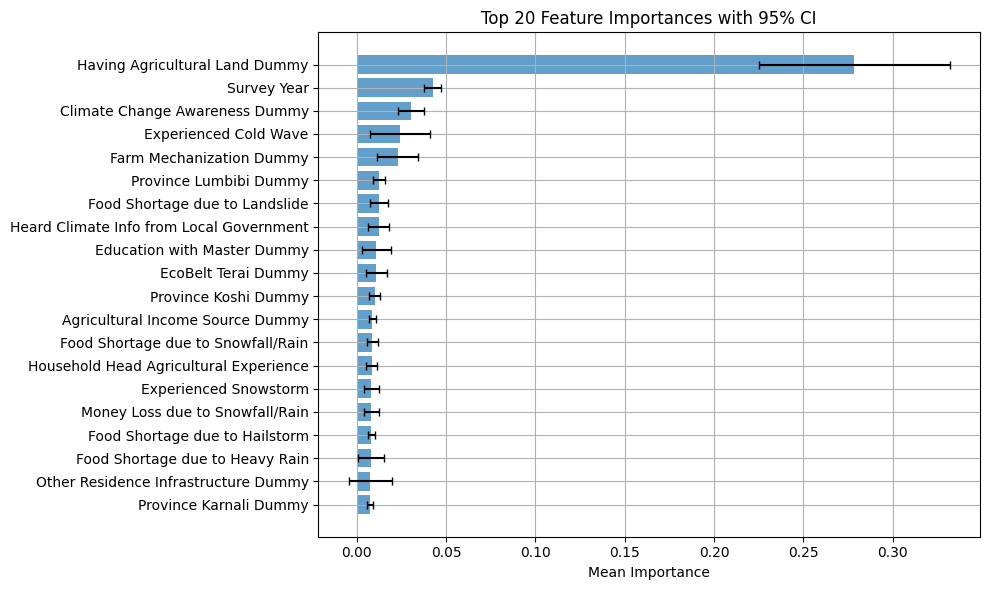

In [45]:
top20 = import_df.sort_values("Mean_Importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(
    top20.index, 
    top20["Mean_Importance"], 
    xerr=top20["Std_Importance"] * 1.96, 
    align="center", 
    alpha=0.7, 
    ecolor="black", 
    capsize=3
)
plt.xlabel("Mean Importance")
plt.title("Top 20 Feature Importances with 95% CI")
plt.grid()
plt.gca().invert_yaxis()  # largest on top
plt.tight_layout()
plt.show()

In [91]:
top20.index

Index(['Having Agricultural Land Dummy', 'Survey Year',
       'Climate Change Awareness Dummy', 'Experienced Cold Wave',
       'Farm Mechanization Dummy', 'Province Lumbibi Dummy',
       'Food Shortage due to Landslide',
       'Heard Climate Info from Local Government',
       'Education with Master Dummy', 'EcoBelt Terai Dummy',
       'Province Koshi Dummy', 'Agricultural Income Source Dummy',
       'Food Shortage due to Snowfall/Rain',
       'Household Head Agricultural Experience', 'Experienced Snowstorm',
       'Money Loss due to Snowfall/Rain', 'Food Shortage due to Hailstorm',
       'Food Shortage due to Heavy Rain',
       'Other Residence Infrastructure Dummy', 'Province Karnali Dummy'],
      dtype='object')

### Climate Change Awareness Dummy

In [92]:
name = 'Climate Change Awareness Dummy'

In [93]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [94]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [95]:
prob_matrix.mean().mean()

0.00835760986426254

In [96]:
prob_matrix.mean().std()

0.0004997958855713316

In [97]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

0.00933720979998235

In [98]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

0.00737800992854273

In [99]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

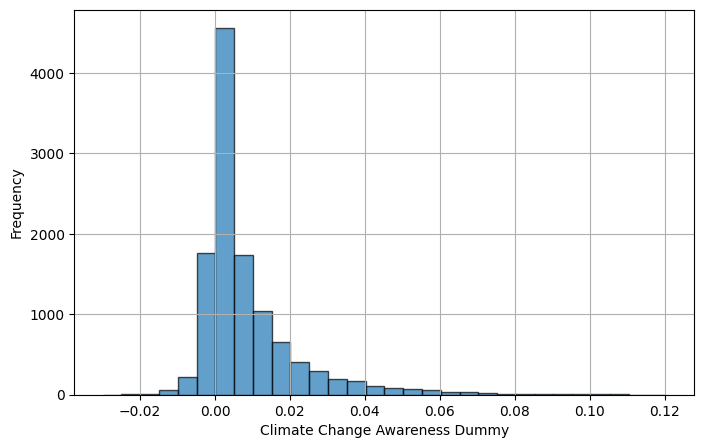

In [100]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Survey Year

In [101]:
name = 'Survey Year'

In [102]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [103]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 2022
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 2016
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [104]:
prob_matrix.mean().mean()

-0.2120374436753863

In [105]:
prob_matrix.mean().std()

0.011505378081477306

In [106]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

-0.1894869026356908

In [107]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

-0.2345879847150818

In [108]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

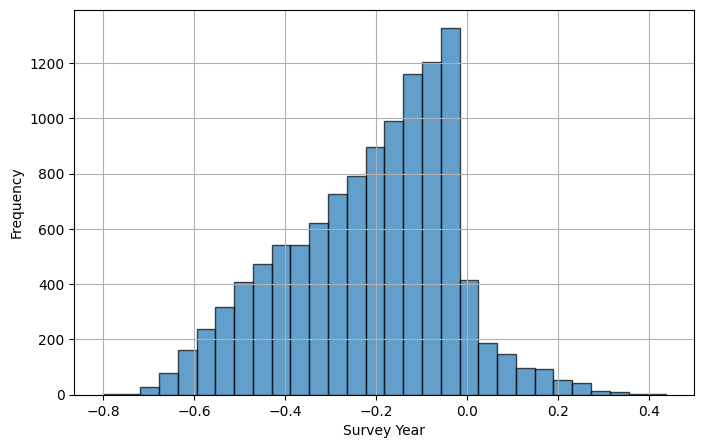

In [109]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

## Checking "RiskReductionPast25"

### Dataset building

In [37]:
print(df_all.columns.tolist())

['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor', 'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', 'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', 'Household_memberNum', 'Own_Resid', 'Resid_Type', 'WaterS1', 'WaterS2', 'WaterS3', 'CookFuelS1', 'CookFuelS2', 'CookFuelS3', 'LightEnergy', 'Toilet', 'IncomeS1', 'IncomeS2', 'IncomeS3', 'Remittance_dummy', 'Have_AgriLand', 'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy', 'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy', 'HouseHead_AgriExpYear', 'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 'FramMechan', 'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome', 'HeardClimate_Dummy', 'ClimateChanged_Dummy', 'ClimateInf

In [38]:
df_inuse = df_all[[# target and features
                    'RiskReductionPast25',
                    
                    # fearures
                    'ClimateChanged_Dummy', 'HeardClimate_Dummy', 
                   'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 
                   'Edu_Bachelor', 'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 
                   'Prov_Bagmati', 'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
                   'Prov_Gandaki', 'Prov_Karnali', # location     
                   'ResidenceOwn_dummy', 'ResidenceRent_dummy', 'ResidenceInstitu_dummy', 'ResidenceOthers_dummy',
                   'ResidInfraPerman_dummy', 'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy', 'ResidInfraOthers_dummy', # house
                    'Remittance_dummy', 
                   'Have_AgriLand', 'HouseHead_AgriExpYear',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 
                   'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 
                   'FramMechan',
                    'IncomeResAgri_dummy', 'IncomeResWage_dummy', 'IncomeResNonAgriBusi_dummy', 'IncomeResRemit_dummy',
                   'IncomeResOthers_dummy', 
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome',
                   'Year',
                   
                   # Awareness sources
                   'ClimateInfo_Radio', 'ClimateInfo_Telev', 'ClimateInfo_News ', 
                   'ClimateInfo_Aware', 'ClimateInfo_Local', 'ClimateInfo_Neigh', 
                   'ClimateInfo_Famil', 'ClimateInfo_Other',
                   
                   # Disaster experiences
                   'ExpDummyDR', 'ExpDummyFF', 'ExpDummyFS', 'ExpDummyFL', 'ExpDummyIN', 'ExpDummyWS', 
                   'ExpDummyTS', 'ExpDummyHS', 'ExpDummyHR', 'ExpDummySR', 'ExpDummySE', 'ExpDummyLS', 
                   'ExpDummySS', 'ExpDummyAV', 'ExpDummyGLOF', 'ExpDummyHW', 'ExpDummyCW', 'ExpDummyDI', 
                   'ExpDummyOT',
                   
                   # DisasterFoodShortage
                   'DisasterFoodShortage_DummyDR', 'DisasterFoodShortage_DummyFF', 'DisasterFoodShortage_DummyFS', 
                   'DisasterFoodShortage_DummyFL', 'DisasterFoodShortage_DummyIN', 'DisasterFoodShortage_DummyWS', 
                   'DisasterFoodShortage_DummyTS', 'DisasterFoodShortage_DummyHS', 'DisasterFoodShortage_DummyHR', 
                   'DisasterFoodShortage_DummySR', 'DisasterFoodShortage_DummySE', 'DisasterFoodShortage_DummyLS', 
                   'DisasterFoodShortage_DummySS', 'DisasterFoodShortage_DummyAV', 'DisasterFoodShortage_DummyGLOF', 
                   'DisasterFoodShortage_DummyHW', 'DisasterFoodShortage_DummyCW', 'DisasterFoodShortage_DummyDI', 
                   'DisasterFoodShortage_DummyOT', 'DisasterDie_DummyDR', 
                   
                   # DisasterDie
                   'DisasterDie_DummyFF', 'DisasterDie_DummyFS', 'DisasterDie_DummyFL', 'DisasterDie_DummyIN', 
                   'DisasterDie_DummyWS', 'DisasterDie_DummyTS', 'DisasterDie_DummyHS', 'DisasterDie_DummyHR', 
                   'DisasterDie_DummySR', 'DisasterDie_DummySE', 'DisasterDie_DummyLS', 'DisasterDie_DummySS', 
                   'DisasterDie_DummyAV', 'DisasterDie_DummyGLOF', 'DisasterDie_DummyHW', 'DisasterDie_DummyCW', 
                   'DisasterDie_DummyDI', 'DisasterDie_DummyOT', 
                   
                   # DisasterMoneyLoss
                   'DisasterMoneyLoss_DummyDR', 'DisasterMoneyLoss_DummyFF', 'DisasterMoneyLoss_DummyFS', 
                   'DisasterMoneyLoss_DummyFL', 'DisasterMoneyLoss_DummyIN', 'DisasterMoneyLoss_DummyWS', 
                   'DisasterMoneyLoss_DummyTS', 'DisasterMoneyLoss_DummyHS', 'DisasterMoneyLoss_DummyHR', 
                   'DisasterMoneyLoss_DummySR', 'DisasterMoneyLoss_DummySE', 'DisasterMoneyLoss_DummyLS', 
                   'DisasterMoneyLoss_DummySS', 'DisasterMoneyLoss_DummyAV', 'DisasterMoneyLoss_DummyGLOF',
                   'DisasterMoneyLoss_DummyHW', 'DisasterMoneyLoss_DummyCW', 'DisasterMoneyLoss_DummyDI', 
                   'DisasterMoneyLoss_DummyOT'
]]

In [39]:
variname_readable = {'ClimateChanged_Dummy':'Climate Change Awareness Dummy',
                     'HeardClimate_Dummy':'Heard about Climate Change Dummy', 'Respon_Female':'Female Dummy', 
                     'Respon_Age':'Age', 'LivingYear':'Years Living in Community', 'Edu_UnderSLC':'Education under Secondary Certificate Dummy', 
                     'Edu_Certificate':'Education with Secondary Certificate Dummy', 'Edu_Bachelor':'Education with Bachelor Dummy', 
                     'Edu_Master':'Education with Master Dummy',  'Edu_PhD':'Education with PhD Dummy', 
                     'Edu_Literal':'Literate Education Dummy',  'Edu_Illiterate':'Illiterate Dummy', 'Edu_year':'Education Year',
                     'Female_Ratio':'Female Ratio in Household', 'U18_Ratio':'Member Under 18 Ratio', 'A65_Ratio':'Seniors Ratio',
                     'Edu12_Ratio':"Member with 12-Year Education or above Ratio", "Literal_Ratio": "Literate Member Ratio",
                     'EcoBelt_Hill': "EcoBelt Hill Dummy", 'EcoBelt_Mountain': "EcoBelt Mountain Dummy", 'EcoBelt_Terai': "EcoBelt Terai Dummy",
                     'Prov_Bagmati': "Province Bagmati Dummy", 'Prov_Koshi': "Province Koshi Dummy", 'Prov_Lumbini': "Province Lumbibi Dummy",
                     'Prov_Madhesh': "Province Madhesh Dummy", 'Prov_Sudurpaschim': "Province Sudurpaschim Dummy", 'Prov_Gandaki': "Province Gandaki Dummy",
                     'Prov_Karnali': "Province Karnali Dummy",
                     'ResidenceOwn_dummy': "Owned Residence Ownership Dummy", 'ResidenceRent_dummy': 'Rented Residence Ownership Dummy', 
                     'ResidenceInstitu_dummy': 'Institutional Residence Ownership Dummy', 'ResidenceOthers_dummy': 'Other-type Residence Ownership Dummy',
                     'ResidInfraPerman_dummy': 'Permanent Residence Dummy', 'ResidInfraSemi_dummy': 'Semi-Permanent Residence Dummy', 
                     'ResidInfraKachchi_dummy': "Kachchi Residence Dummy", 'ResidInfraOthers_dummy': 'Other Residence Infrastructure Dummy', # house
                     'Remittance_dummy' : "Have Remittance",
                     'Have_AgriLand': "Having Agricultural Land Dummy", 'HouseHead_AgriExpYear': "Household Head Agricultural Experience",
                     'Radio_dummy': "Having Radio Dummy", 'TV_dummy': "Having TV Dummy", 'PC_dummy': "Having Computer Dummy", 'Net_dummy': "Having Internet Dummy",
                     'Phone_dummy': "Having Telephone Dummy", 'Mobile_dummy': "Having Mobile Dummy", 'Motorbike_dummy': "Having Motorbike Dummy", 
                     'Car_dummy': "Having Car Dummy", 'Bike_dummy': "Having Bike Dummy", 'OtherVehi_dummy': "Having Other Vehicle Dummy", 
                     'Refrige_dummy':"Having Refrigator Dummy",
                     'SavingMembership': "Saving Membership Dummy", 'RegularSaving': 'Having Regular Saving Dummy', 
                     'OrgMembership': 'Having Organization Membership Dummy', 'AgriSupport':'Agricultural Supporting Dummy', 
                     'Dist_Road': 'Distance to Motorable Road', 'Dist_HealthCenter': "Distance to Health Center", 
                     'Dist_SecondarySchool': "Distance to Secondary School", 'Dist_Market':"Distance to Market", 'Dist_AgriSupport': 'Distance to Agricultural Center', 
                     'FramMechan':'Farm Mechanization Dummy',
                     'IncomeResAgri_dummy': "Agricultural Income Source Dummy", 'IncomeResWage_dummy': "Wage Income Source Dummy",
                     'IncomeResNonAgriBusi_dummy': "Non-Agricultural Business Income Source Dummy", 'IncomeResRemit_dummy': "Remittance Income Dummy",
                     'IncomeResOthers_dummy': "Others Income Source Dummy", 
                     'CropIncome': "Crop Income", 'LivestockIncome': "Livestock Income", 'NonAgriIncome': "Non-agricultural Income", 
                     'BusiIncome': "Business Income", 'TotalIncome': "Total Income",
                     'Year': "Survey Year",
                                         
                    }

In [40]:
# ...existing code...
variname_readable.update({
    # Awareness sources
    'ClimateInfo_Radio': "Heard Climate Info from Radio",
    'ClimateInfo_Telev': "Heard Climate Info from Television",
    'ClimateInfo_News ': "Heard Climate Info from Newspaper",
    'ClimateInfo_Aware': "Heard Climate Info from Awareness Program",
    'ClimateInfo_Local': "Heard Climate Info from Local Government",
    'ClimateInfo_Neigh': "Heard Climate Info from Neighbors",
    'ClimateInfo_Famil': "Heard Climate Info from Family",
    'ClimateInfo_Other': "Heard Climate Info from Other Sources",

    # Disaster experiences
    'ExpDummyDR': "Experienced Drought",
    'ExpDummyFF': "Experienced Flash Flood",
    'ExpDummyFS': "Experienced Forest Fire",
    'ExpDummyFL': "Experienced Flood",
    'ExpDummyIN': "Experienced Insect Infestation",
    'ExpDummyWS': "Experienced Windstorm",
    'ExpDummyTS': "Experienced Thunderstorm",
    'ExpDummyHS': "Experienced Hailstorm",
    'ExpDummyHR': "Experienced Heavy Rain",
    'ExpDummySR': "Experienced Snowfall/Rain",
    'ExpDummySE': "Experienced Earthquake",
    'ExpDummyLS': "Experienced Landslide",
    'ExpDummySS': "Experienced Snowstorm",
    'ExpDummyAV': "Experienced Avalanche",
    'ExpDummyGLOF': "Experienced Glacial Lake Outburst Flood",
    'ExpDummyHW': "Experienced Heat Wave",
    'ExpDummyCW': "Experienced Cold Wave",
    'ExpDummyDI': "Experienced Disease Outbreak",
    'ExpDummyOT': "Experienced Other Disaster",

    # Disaster Food Shortage
    'DisasterFoodShortage_DummyDR': "Food Shortage due to Drought",
    'DisasterFoodShortage_DummyFF': "Food Shortage due to Flash Flood",
    'DisasterFoodShortage_DummyFS': "Food Shortage due to Forest Fire",
    'DisasterFoodShortage_DummyFL': "Food Shortage due to Flood",
    'DisasterFoodShortage_DummyIN': "Food Shortage due to Insect Infestation",
    'DisasterFoodShortage_DummyWS': "Food Shortage due to Windstorm",
    'DisasterFoodShortage_DummyTS': "Food Shortage due to Thunderstorm",
    'DisasterFoodShortage_DummyHS': "Food Shortage due to Hailstorm",
    'DisasterFoodShortage_DummyHR': "Food Shortage due to Heavy Rain",
    'DisasterFoodShortage_DummySR': "Food Shortage due to Snowfall/Rain",
    'DisasterFoodShortage_DummySE': "Food Shortage due to Earthquake",
    'DisasterFoodShortage_DummyLS': "Food Shortage due to Landslide",
    'DisasterFoodShortage_DummySS': "Food Shortage due to Snowstorm",
    'DisasterFoodShortage_DummyAV': "Food Shortage due to Avalanche",
    'DisasterFoodShortage_DummyGLOF': "Food Shortage due to GLOF",
    'DisasterFoodShortage_DummyHW': "Food Shortage due to Heat Wave",
    'DisasterFoodShortage_DummyCW': "Food Shortage due to Cold Wave",
    'DisasterFoodShortage_DummyDI': "Food Shortage due to Disease Outbreak",
    'DisasterFoodShortage_DummyOT': "Food Shortage due to Other Disaster",
    'DisasterDie_DummyDR': "Death due to Drought",

    # Disaster Die
    'DisasterDie_DummyFF': "Death due to Flash Flood",
    'DisasterDie_DummyFS': "Death due to Forest Fire",
    'DisasterDie_DummyFL': "Death due to Flood",
    'DisasterDie_DummyIN': "Death due to Insect Infestation",
    'DisasterDie_DummyWS': "Death due to Windstorm",
    'DisasterDie_DummyTS': "Death due to Thunderstorm",
    'DisasterDie_DummyHS': "Death due to Hailstorm",
    'DisasterDie_DummyHR': "Death due to Heavy Rain",
    'DisasterDie_DummySR': "Death due to Snowfall/Rain",
    'DisasterDie_DummySE': "Death due to Earthquake",
    'DisasterDie_DummyLS': "Death due to Landslide",
    'DisasterDie_DummySS': "Death due to Snowstorm",
    'DisasterDie_DummyAV': "Death due to Avalanche",
    'DisasterDie_DummyGLOF': "Death due to GLOF",
    'DisasterDie_DummyHW': "Death due to Heat Wave",
    'DisasterDie_DummyCW': "Death due to Cold Wave",
    'DisasterDie_DummyDI': "Death due to Disease Outbreak",
    'DisasterDie_DummyOT': "Death due to Other Disaster",

    # Disaster Money Loss
    'DisasterMoneyLoss_DummyDR': "Money Loss due to Drought",
    'DisasterMoneyLoss_DummyFF': "Money Loss due to Flash Flood",
    'DisasterMoneyLoss_DummyFS': "Money Loss due to Forest Fire",
    'DisasterMoneyLoss_DummyFL': "Money Loss due to Flood",
    'DisasterMoneyLoss_DummyIN': "Money Loss due to Insect Infestation",
    'DisasterMoneyLoss_DummyWS': "Money Loss due to Windstorm",
    'DisasterMoneyLoss_DummyTS': "Money Loss due to Thunderstorm",
    'DisasterMoneyLoss_DummyHS': "Money Loss due to Hailstorm",
    'DisasterMoneyLoss_DummyHR': "Money Loss due to Heavy Rain",
    'DisasterMoneyLoss_DummySR': "Money Loss due to Snowfall/Rain",
    'DisasterMoneyLoss_DummySE': "Money Loss due to Earthquake",
    'DisasterMoneyLoss_DummyLS': "Money Loss due to Landslide",
    'DisasterMoneyLoss_DummySS': "Money Loss due to Snowstorm",
    'DisasterMoneyLoss_DummyAV': "Money Loss due to Avalanche",
    'DisasterMoneyLoss_DummyGLOF': "Money Loss due to GLOF",
    'DisasterMoneyLoss_DummyHW': "Money Loss due to Heat Wave",
    'DisasterMoneyLoss_DummyCW': "Money Loss due to Cold Wave",
    'DisasterMoneyLoss_DummyDI': "Money Loss due to Disease Outbreak",
    'DisasterMoneyLoss_DummyOT': "Money Loss due to Other Disaster",
})
# ...existing code...

In [41]:
variname_readable.update({'RiskReductionPast25': 'Risk Reduction Measures in Past 25 Years Dummy'})

In [42]:
data_summary = df_inuse.describe().T

In [43]:
data_summary.index = data_summary.index.map(variname_readable)

In [44]:
data_summary.to_excel("MLD01e_Results/Table03_DataSummaryAction_RiskReductionPast25.xlsx")

In [45]:
data_summary

,count,mean,std,min,25%,50%,75%,max
Risk Reduction Measures in Past 25 Years Dummy,11568.0,0.241269,0.427872,0.0,0.0,0.0,0.0,1.0
Climate Change Awareness Dummy,11568.0,0.901020,0.298648,0.0,1.0,1.0,1.0,1.0
Heard about Climate Change Dummy,11568.0,0.421508,0.493822,0.0,0.0,0.0,1.0,1.0
Female Dummy,11568.0,0.285183,0.451521,0.0,0.0,0.0,1.0,1.0
Age,11568.0,58.681189,10.276510,45.0,50.0,58.0,66.0,95.0
...,...,...,...,...,...,...,...,...
Money Loss due to GLOF,11568.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Money Loss due to Heat Wave,11568.0,0.000519,0.022769,0.0,0.0,0.0,0.0,1.0
Money Loss due to Cold Wave,11568.0,0.020228,0.140786,0.0,0.0,0.0,0.0,1.0
Money Loss due to Disease Outbreak,11568.0,0.127161,0.333168,0.0,0.0,0.0,0.0,1.0


In [46]:
df_inuse.columns = df_inuse.columns.map(variname_readable)

### Hyper Tunining

In [47]:
y = df_inuse['Risk Reduction Measures in Past 25 Years Dummy'].astype(int)
X = df_inuse.drop(columns=['Risk Reduction Measures in Past 25 Years Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [48]:
clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    device = 'cuda'
)

In [49]:
param_distributions = {
    'n_estimators': [200, 500, 1_000, 2_000],
    'max_depth': [4,  8, 16],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 5, 10]
}

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=200,                 # increase for a more exhaustive search if you have time
    scoring='accuracy',
    return_train_score=True,
    cv=cv,
    verbose=3,
    refit=True,                # refit on entire data with best params
    random_state=42
)

search.fit(X, y)

Fitting 10 folds for each of 200 candidates, totalling 2000 fits
[CV 1/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.828) total time=  10.4s
[CV 2/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.844) total time=   9.8s
[CV 3/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.841) total time=   9.7s
[CV 4/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.846) total time=  10.0s
[CV 5/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=1.000, test=0.848) total time=   9.6s
[CV 6/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=

In [ ]:
# 7) Results
print("Best mean CV accuracy:", f"{search.best_score_:.4f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

In [ ]:
cvres = pd.DataFrame(search.cv_results_)

In [ ]:
cvres.to_parquet('MLD01e_Results/MLD01e_C03_ActionFactorInvestigation_RiskReductionPast25.parquet')

In [ ]:
cols = ['mean_test_score', 'std_test_score', 'rank_test_score'] + [c for c in cvres.columns if c.startswith('param_')]
cvres_sorted = cvres.sort_values('rank_test_score')[cols].head(10)

In [ ]:
cvres_sorted

### 10-fold 10-epoch Estimation

In [126]:
y = df_inuse['Risk Reduction Measures in Past 25 Years Dummy'].astype(int)
X = df_inuse.drop(columns=['Risk Reduction Measures in Past 25 Years Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [127]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [128]:
def Metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

    return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]

In [129]:
prob_matrix = np.zeros([X.shape[0], 10])

In [130]:
acc_lines = []
importances_df = []
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for random_seed in range(42, 42*11, 42):
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=1000, max_depth=16,
            learning_rate=0.05, subsample=0.9,
            colsample_bytree=1.0, min_child_weight=1, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)


        metrics = Metrics(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred).flatten()
        line  = [fold, random_seed] + metrics + list(cm)
        importances = clf.feature_importances_

        acc_lines.append(line)
        importances_df.append(importances)
        
    

fold: 1, random_seed:42
Accuracy: 0.8444252376836646
Precision: 0.7239819004524887
Recall   : 0.5734767025089605
F1-score : 0.64
fold: 1, random_seed:84
Accuracy: 0.8547968885047537
Precision: 0.751131221719457
Recall   : 0.5949820788530465
F1-score : 0.664
fold: 1, random_seed:126
Accuracy: 0.8487467588591184
Precision: 0.7407407407407407
Recall   : 0.5734767025089605
F1-score : 0.6464646464646465
fold: 1, random_seed:168
Accuracy: 0.8409680207433017
Precision: 0.7111111111111111
Recall   : 0.5734767025089605
F1-score : 0.6349206349206349
fold: 1, random_seed:210
Accuracy: 0.8539325842696629
Precision: 0.7477477477477478
Recall   : 0.5949820788530465
F1-score : 0.6626746506986028
fold: 1, random_seed:252
Accuracy: 0.8522039757994814
Precision: 0.7432432432432432
Recall   : 0.5913978494623656
F1-score : 0.6586826347305389
fold: 1, random_seed:294
Accuracy: 0.8513396715643907
Precision: 0.7377777777777778
Recall   : 0.5949820788530465
F1-score : 0.6587301587301587
fold: 1, random_seed:3

KeyboardInterrupt: 

In [ ]:
acc_df = pd.DataFrame(acc_lines)

In [ ]:
acc_df.columns = ['fold', 'random_seed', 'acc', 'prec', 'recall', 'f1', 'TN', 'FP', 'FN', 'TP']

In [ ]:
acc_df.to_excel('MLD01e_Results/Table_C03_AccuracyTableAction_RiskReductionPast25.xlsx')


In [ ]:
acc_df[['acc', 'prec', 'recall', 'f1']].mean(axis=0)

acc       0.863001
prec      0.703028
recall    0.605461
f1        0.650198
dtype: float64

In [ ]:
import_df = pd.DataFrame(importances_df).T

In [ ]:
import_df.index = X.columns

In [ ]:
import_df['Mean_Importance'] = import_df.iloc[:,:100].mean(axis = 1)
import_df['Std_Importance'] = import_df.iloc[:,:100].std(axis = 1)

In [ ]:
import_df['Mean_Importance'] 

Climate Change Awareness Dummy           0.004997
Heard about Climate Change Dummy         0.008319
Female Dummy                             0.004117
Age                                      0.003195
Years Living in Community                0.003388
                                           ...   
Money Loss due to Heat Wave              0.000091
Money Loss due to Cold Wave              0.006310
Money Loss due to Disease Outbreak       0.004127
Money Loss due to Other Disaster         0.000136
Total Money Loss (NRs) due to Drought    0.003907
Name: Mean_Importance, Length: 156, dtype: float32

In [ ]:
# Get importance values
importances = pd.Series(import_df['Mean_Importance'] , index=import_df.index)

# Sort descending
importances = importances.sort_values(ascending=False)

print(importances.head(20))   # Top 20 important features

Survey Year                                 0.141159
Having Agricultural Land Dummy              0.074941
Province Koshi Dummy                        0.044982
Farm Mechanization Dummy                    0.024447
Experienced Earthquake                      0.021269
Heard Climate Info from Other Sources       0.016808
Food Shortage due to Flash Flood            0.015556
Food Shortage due to Disease Outbreak       0.015095
Other-type Residence Ownership Dummy        0.014033
Death due to Cold Wave                      0.013907
Province Bagmati Dummy                      0.012964
Province Gandaki Dummy                      0.011746
Food Shortage due to Forest Fire            0.011138
Death due to Disease Outbreak               0.010698
Money Loss due to Insect Infestation        0.010308
Death due to Heat Wave                      0.010086
Province Sudurpaschim Dummy                 0.010072
Experienced Flash Flood                     0.010044
Education with Master Dummy                 0.

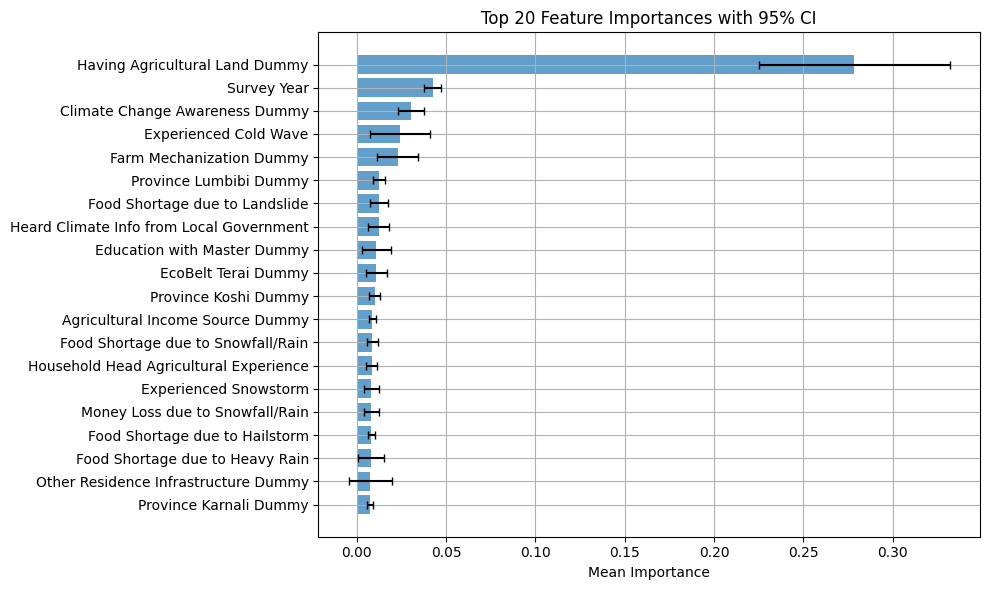

In [ ]:
top20 = import_df.sort_values("Mean_Importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(
    top20.index, 
    top20["Mean_Importance"], 
    xerr=top20["Std_Importance"] * 1.96, 
    align="center", 
    alpha=0.7, 
    ecolor="black", 
    capsize=3
)
plt.xlabel("Mean Importance")
plt.title("Top 20 Feature Importances with 95% CI")
plt.grid()
plt.gca().invert_yaxis()  # largest on top
plt.tight_layout()
plt.show()

In [ ]:
top20.index

Index(['Having Agricultural Land Dummy', 'Survey Year',
       'Climate Change Awareness Dummy', 'Experienced Cold Wave',
       'Farm Mechanization Dummy', 'Province Lumbibi Dummy',
       'Food Shortage due to Landslide',
       'Heard Climate Info from Local Government',
       'Education with Master Dummy', 'EcoBelt Terai Dummy',
       'Province Koshi Dummy', 'Agricultural Income Source Dummy',
       'Food Shortage due to Snowfall/Rain',
       'Household Head Agricultural Experience', 'Experienced Snowstorm',
       'Money Loss due to Snowfall/Rain', 'Food Shortage due to Hailstorm',
       'Food Shortage due to Heavy Rain',
       'Other Residence Infrastructure Dummy', 'Province Karnali Dummy'],
      dtype='object')

### Climate Change Awareness Dummy

In [ ]:
name = 'Climate Change Awareness Dummy'

In [ ]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [ ]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [ ]:
prob_matrix.mean().mean()

0.00835760986426254

In [ ]:
prob_matrix.mean().std()

0.0004997958855713316

In [ ]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

0.00933720979998235

In [ ]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

0.00737800992854273

In [ ]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

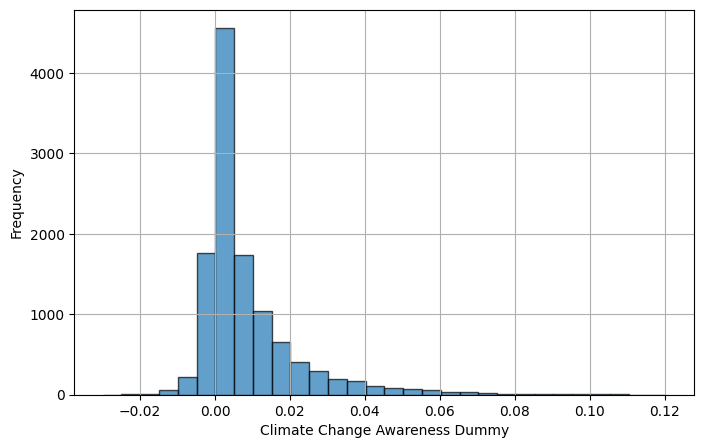

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Survey Year

In [ ]:
name = 'Survey Year'

In [ ]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [ ]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 2022
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 2016
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [ ]:
prob_matrix.mean().mean()

-0.1146819796581285

In [ ]:
prob_matrix.mean().std()

0.009940544633862408

In [ ]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

-0.09519851217575818

In [ ]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

-0.13416544714049883

In [ ]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

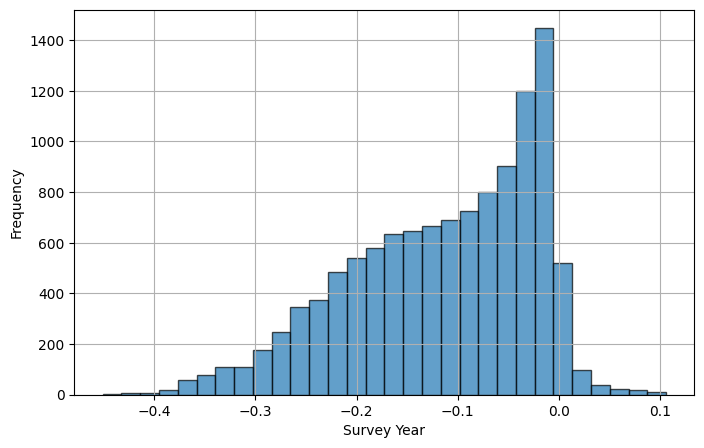

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

## Checking "RoadImprovementPast25"

### Dataset building

In [ ]:
print(df_all.columns.tolist())

In [ ]:
df_inuse = df_all[[# target and features
                    'RoadImprovementPast25',
                    
                    # fearures
                    'ClimateChanged_Dummy', 'HeardClimate_Dummy', 
                   'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 
                   'Edu_Bachelor', 'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 
                   'Prov_Bagmati', 'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
                   'Prov_Gandaki', 'Prov_Karnali', # location     
                   'ResidenceOwn_dummy', 'ResidenceRent_dummy', 'ResidenceInstitu_dummy', 'ResidenceOthers_dummy',
                   'ResidInfraPerman_dummy', 'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy', 'ResidInfraOthers_dummy', # house
                    'Remittance_dummy', 
                   'Have_AgriLand', 'HouseHead_AgriExpYear',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 
                   'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 
                   'FramMechan',
                    'IncomeResAgri_dummy', 'IncomeResWage_dummy', 'IncomeResNonAgriBusi_dummy', 'IncomeResRemit_dummy',
                   'IncomeResOthers_dummy', 
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome',
                   'Year',
                   
                   # Awareness sources
                   'ClimateInfo_Radio', 'ClimateInfo_Telev', 'ClimateInfo_News ', 
                   'ClimateInfo_Aware', 'ClimateInfo_Local', 'ClimateInfo_Neigh', 
                   'ClimateInfo_Famil', 'ClimateInfo_Other',
                   
                   # Disaster experiences
                   'ExpDummyDR', 'ExpDummyFF', 'ExpDummyFS', 'ExpDummyFL', 'ExpDummyIN', 'ExpDummyWS', 
                   'ExpDummyTS', 'ExpDummyHS', 'ExpDummyHR', 'ExpDummySR', 'ExpDummySE', 'ExpDummyLS', 
                   'ExpDummySS', 'ExpDummyAV', 'ExpDummyGLOF', 'ExpDummyHW', 'ExpDummyCW', 'ExpDummyDI', 
                   'ExpDummyOT',
                   
                   # DisasterFoodShortage
                   'DisasterFoodShortage_DummyDR', 'DisasterFoodShortage_DummyFF', 'DisasterFoodShortage_DummyFS', 
                   'DisasterFoodShortage_DummyFL', 'DisasterFoodShortage_DummyIN', 'DisasterFoodShortage_DummyWS', 
                   'DisasterFoodShortage_DummyTS', 'DisasterFoodShortage_DummyHS', 'DisasterFoodShortage_DummyHR', 
                   'DisasterFoodShortage_DummySR', 'DisasterFoodShortage_DummySE', 'DisasterFoodShortage_DummyLS', 
                   'DisasterFoodShortage_DummySS', 'DisasterFoodShortage_DummyAV', 'DisasterFoodShortage_DummyGLOF', 
                   'DisasterFoodShortage_DummyHW', 'DisasterFoodShortage_DummyCW', 'DisasterFoodShortage_DummyDI', 
                   'DisasterFoodShortage_DummyOT', 'DisasterDie_DummyDR', 
                   
                   # DisasterDie
                   'DisasterDie_DummyFF', 'DisasterDie_DummyFS', 'DisasterDie_DummyFL', 'DisasterDie_DummyIN', 
                   'DisasterDie_DummyWS', 'DisasterDie_DummyTS', 'DisasterDie_DummyHS', 'DisasterDie_DummyHR', 
                   'DisasterDie_DummySR', 'DisasterDie_DummySE', 'DisasterDie_DummyLS', 'DisasterDie_DummySS', 
                   'DisasterDie_DummyAV', 'DisasterDie_DummyGLOF', 'DisasterDie_DummyHW', 'DisasterDie_DummyCW', 
                   'DisasterDie_DummyDI', 'DisasterDie_DummyOT', 
                   
                   # DisasterMoneyLoss
                   'DisasterMoneyLoss_DummyDR', 'DisasterMoneyLoss_DummyFF', 'DisasterMoneyLoss_DummyFS', 
                   'DisasterMoneyLoss_DummyFL', 'DisasterMoneyLoss_DummyIN', 'DisasterMoneyLoss_DummyWS', 
                   'DisasterMoneyLoss_DummyTS', 'DisasterMoneyLoss_DummyHS', 'DisasterMoneyLoss_DummyHR', 
                   'DisasterMoneyLoss_DummySR', 'DisasterMoneyLoss_DummySE', 'DisasterMoneyLoss_DummyLS', 
                   'DisasterMoneyLoss_DummySS', 'DisasterMoneyLoss_DummyAV', 'DisasterMoneyLoss_DummyGLOF',
                   'DisasterMoneyLoss_DummyHW', 'DisasterMoneyLoss_DummyCW', 'DisasterMoneyLoss_DummyDI', 
                   'DisasterMoneyLoss_DummyOT'
]]

In [ ]:
variname_readable = {'ClimateChanged_Dummy':'Climate Change Awareness Dummy',
                     'HeardClimate_Dummy':'Heard about Climate Change Dummy', 'Respon_Female':'Female Dummy', 
                     'Respon_Age':'Age', 'LivingYear':'Years Living in Community', 'Edu_UnderSLC':'Education under Secondary Certificate Dummy', 
                     'Edu_Certificate':'Education with Secondary Certificate Dummy', 'Edu_Bachelor':'Education with Bachelor Dummy', 
                     'Edu_Master':'Education with Master Dummy',  'Edu_PhD':'Education with PhD Dummy', 
                     'Edu_Literal':'Literate Education Dummy',  'Edu_Illiterate':'Illiterate Dummy', 'Edu_year':'Education Year',
                     'Female_Ratio':'Female Ratio in Household', 'U18_Ratio':'Member Under 18 Ratio', 'A65_Ratio':'Seniors Ratio',
                     'Edu12_Ratio':"Member with 12-Year Education or above Ratio", "Literal_Ratio": "Literate Member Ratio",
                     'EcoBelt_Hill': "EcoBelt Hill Dummy", 'EcoBelt_Mountain': "EcoBelt Mountain Dummy", 'EcoBelt_Terai': "EcoBelt Terai Dummy",
                     'Prov_Bagmati': "Province Bagmati Dummy", 'Prov_Koshi': "Province Koshi Dummy", 'Prov_Lumbini': "Province Lumbibi Dummy",
                     'Prov_Madhesh': "Province Madhesh Dummy", 'Prov_Sudurpaschim': "Province Sudurpaschim Dummy", 'Prov_Gandaki': "Province Gandaki Dummy",
                     'Prov_Karnali': "Province Karnali Dummy",
                     'ResidenceOwn_dummy': "Owned Residence Ownership Dummy", 'ResidenceRent_dummy': 'Rented Residence Ownership Dummy', 
                     'ResidenceInstitu_dummy': 'Institutional Residence Ownership Dummy', 'ResidenceOthers_dummy': 'Other-type Residence Ownership Dummy',
                     'ResidInfraPerman_dummy': 'Permanent Residence Dummy', 'ResidInfraSemi_dummy': 'Semi-Permanent Residence Dummy', 
                     'ResidInfraKachchi_dummy': "Kachchi Residence Dummy", 'ResidInfraOthers_dummy': 'Other Residence Infrastructure Dummy', # house
                     'Remittance_dummy' : "Have Remittance",
                     'Have_AgriLand': "Having Agricultural Land Dummy", 'HouseHead_AgriExpYear': "Household Head Agricultural Experience",
                     'Radio_dummy': "Having Radio Dummy", 'TV_dummy': "Having TV Dummy", 'PC_dummy': "Having Computer Dummy", 'Net_dummy': "Having Internet Dummy",
                     'Phone_dummy': "Having Telephone Dummy", 'Mobile_dummy': "Having Mobile Dummy", 'Motorbike_dummy': "Having Motorbike Dummy", 
                     'Car_dummy': "Having Car Dummy", 'Bike_dummy': "Having Bike Dummy", 'OtherVehi_dummy': "Having Other Vehicle Dummy", 
                     'Refrige_dummy':"Having Refrigator Dummy",
                     'SavingMembership': "Saving Membership Dummy", 'RegularSaving': 'Having Regular Saving Dummy', 
                     'OrgMembership': 'Having Organization Membership Dummy', 'AgriSupport':'Agricultural Supporting Dummy', 
                     'Dist_Road': 'Distance to Motorable Road', 'Dist_HealthCenter': "Distance to Health Center", 
                     'Dist_SecondarySchool': "Distance to Secondary School", 'Dist_Market':"Distance to Market", 'Dist_AgriSupport': 'Distance to Agricultural Center', 
                     'FramMechan':'Farm Mechanization Dummy',
                     'IncomeResAgri_dummy': "Agricultural Income Source Dummy", 'IncomeResWage_dummy': "Wage Income Source Dummy",
                     'IncomeResNonAgriBusi_dummy': "Non-Agricultural Business Income Source Dummy", 'IncomeResRemit_dummy': "Remittance Income Dummy",
                     'IncomeResOthers_dummy': "Others Income Source Dummy", 
                     'CropIncome': "Crop Income", 'LivestockIncome': "Livestock Income", 'NonAgriIncome': "Non-agricultural Income", 
                     'BusiIncome': "Business Income", 'TotalIncome': "Total Income",
                     'Year': "Survey Year",
                                         
                    }

In [ ]:
# ...existing code...
variname_readable.update({
    # Awareness sources
    'ClimateInfo_Radio': "Heard Climate Info from Radio",
    'ClimateInfo_Telev': "Heard Climate Info from Television",
    'ClimateInfo_News ': "Heard Climate Info from Newspaper",
    'ClimateInfo_Aware': "Heard Climate Info from Awareness Program",
    'ClimateInfo_Local': "Heard Climate Info from Local Government",
    'ClimateInfo_Neigh': "Heard Climate Info from Neighbors",
    'ClimateInfo_Famil': "Heard Climate Info from Family",
    'ClimateInfo_Other': "Heard Climate Info from Other Sources",

    # Disaster experiences
    'ExpDummyDR': "Experienced Drought",
    'ExpDummyFF': "Experienced Flash Flood",
    'ExpDummyFS': "Experienced Forest Fire",
    'ExpDummyFL': "Experienced Flood",
    'ExpDummyIN': "Experienced Insect Infestation",
    'ExpDummyWS': "Experienced Windstorm",
    'ExpDummyTS': "Experienced Thunderstorm",
    'ExpDummyHS': "Experienced Hailstorm",
    'ExpDummyHR': "Experienced Heavy Rain",
    'ExpDummySR': "Experienced Snowfall/Rain",
    'ExpDummySE': "Experienced Earthquake",
    'ExpDummyLS': "Experienced Landslide",
    'ExpDummySS': "Experienced Snowstorm",
    'ExpDummyAV': "Experienced Avalanche",
    'ExpDummyGLOF': "Experienced Glacial Lake Outburst Flood",
    'ExpDummyHW': "Experienced Heat Wave",
    'ExpDummyCW': "Experienced Cold Wave",
    'ExpDummyDI': "Experienced Disease Outbreak",
    'ExpDummyOT': "Experienced Other Disaster",

    # Disaster Food Shortage
    'DisasterFoodShortage_DummyDR': "Food Shortage due to Drought",
    'DisasterFoodShortage_DummyFF': "Food Shortage due to Flash Flood",
    'DisasterFoodShortage_DummyFS': "Food Shortage due to Forest Fire",
    'DisasterFoodShortage_DummyFL': "Food Shortage due to Flood",
    'DisasterFoodShortage_DummyIN': "Food Shortage due to Insect Infestation",
    'DisasterFoodShortage_DummyWS': "Food Shortage due to Windstorm",
    'DisasterFoodShortage_DummyTS': "Food Shortage due to Thunderstorm",
    'DisasterFoodShortage_DummyHS': "Food Shortage due to Hailstorm",
    'DisasterFoodShortage_DummyHR': "Food Shortage due to Heavy Rain",
    'DisasterFoodShortage_DummySR': "Food Shortage due to Snowfall/Rain",
    'DisasterFoodShortage_DummySE': "Food Shortage due to Earthquake",
    'DisasterFoodShortage_DummyLS': "Food Shortage due to Landslide",
    'DisasterFoodShortage_DummySS': "Food Shortage due to Snowstorm",
    'DisasterFoodShortage_DummyAV': "Food Shortage due to Avalanche",
    'DisasterFoodShortage_DummyGLOF': "Food Shortage due to GLOF",
    'DisasterFoodShortage_DummyHW': "Food Shortage due to Heat Wave",
    'DisasterFoodShortage_DummyCW': "Food Shortage due to Cold Wave",
    'DisasterFoodShortage_DummyDI': "Food Shortage due to Disease Outbreak",
    'DisasterFoodShortage_DummyOT': "Food Shortage due to Other Disaster",
    'DisasterDie_DummyDR': "Death due to Drought",

    # Disaster Die
    'DisasterDie_DummyFF': "Death due to Flash Flood",
    'DisasterDie_DummyFS': "Death due to Forest Fire",
    'DisasterDie_DummyFL': "Death due to Flood",
    'DisasterDie_DummyIN': "Death due to Insect Infestation",
    'DisasterDie_DummyWS': "Death due to Windstorm",
    'DisasterDie_DummyTS': "Death due to Thunderstorm",
    'DisasterDie_DummyHS': "Death due to Hailstorm",
    'DisasterDie_DummyHR': "Death due to Heavy Rain",
    'DisasterDie_DummySR': "Death due to Snowfall/Rain",
    'DisasterDie_DummySE': "Death due to Earthquake",
    'DisasterDie_DummyLS': "Death due to Landslide",
    'DisasterDie_DummySS': "Death due to Snowstorm",
    'DisasterDie_DummyAV': "Death due to Avalanche",
    'DisasterDie_DummyGLOF': "Death due to GLOF",
    'DisasterDie_DummyHW': "Death due to Heat Wave",
    'DisasterDie_DummyCW': "Death due to Cold Wave",
    'DisasterDie_DummyDI': "Death due to Disease Outbreak",
    'DisasterDie_DummyOT': "Death due to Other Disaster",

    # Disaster Money Loss
    'DisasterMoneyLoss_DummyDR': "Money Loss due to Drought",
    'DisasterMoneyLoss_DummyFF': "Money Loss due to Flash Flood",
    'DisasterMoneyLoss_DummyFS': "Money Loss due to Forest Fire",
    'DisasterMoneyLoss_DummyFL': "Money Loss due to Flood",
    'DisasterMoneyLoss_DummyIN': "Money Loss due to Insect Infestation",
    'DisasterMoneyLoss_DummyWS': "Money Loss due to Windstorm",
    'DisasterMoneyLoss_DummyTS': "Money Loss due to Thunderstorm",
    'DisasterMoneyLoss_DummyHS': "Money Loss due to Hailstorm",
    'DisasterMoneyLoss_DummyHR': "Money Loss due to Heavy Rain",
    'DisasterMoneyLoss_DummySR': "Money Loss due to Snowfall/Rain",
    'DisasterMoneyLoss_DummySE': "Money Loss due to Earthquake",
    'DisasterMoneyLoss_DummyLS': "Money Loss due to Landslide",
    'DisasterMoneyLoss_DummySS': "Money Loss due to Snowstorm",
    'DisasterMoneyLoss_DummyAV': "Money Loss due to Avalanche",
    'DisasterMoneyLoss_DummyGLOF': "Money Loss due to GLOF",
    'DisasterMoneyLoss_DummyHW': "Money Loss due to Heat Wave",
    'DisasterMoneyLoss_DummyCW': "Money Loss due to Cold Wave",
    'DisasterMoneyLoss_DummyDI': "Money Loss due to Disease Outbreak",
    'DisasterMoneyLoss_DummyOT': "Money Loss due to Other Disaster",
})
# ...existing code...

In [ ]:
variname_readable.update({'RoadImprovementPast25': 'Participation in Road and Infrastructure Improvement to Protect from Flood/landslide in the Past Dummy'})

In [ ]:
data_summary = df_inuse.describe().T

In [ ]:
data_summary.index = data_summary.index.map(variname_readable)

In [ ]:
data_summary.to_excel("MLD01e_Results/Table03_DataSummaryAction_RoadImprovementPast25.xlsx")

In [ ]:
data_summary

In [ ]:
df_inuse.columns = df_inuse.columns.map(variname_readable)

### Hyper Tunining

In [ ]:
y = df_inuse['Participation in Road and Infrastructure Improvement to Protect from Flood/landslide in the Past Dummy'].astype(int)
X = df_inuse.drop(columns=['Participation in Road and Infrastructure Improvement to Protect from Flood/landslide in the Past Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [ ]:
clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    device = 'cuda'
)

In [ ]:
param_distributions = {
    'n_estimators': [200, 500, 1_000, 2_000],
    'max_depth': [4,  8, 16],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 5, 10]
}

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=200,                 # increase for a more exhaustive search if you have time
    scoring='accuracy',
    return_train_score=True,
    cv=cv,
    verbose=3,
    refit=True,                # refit on entire data with best params
    random_state=42
)

search.fit(X, y)

In [ ]:
# 7) Results
print("Best mean CV accuracy:", f"{search.best_score_:.4f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

In [ ]:
cvres = pd.DataFrame(search.cv_results_)

In [ ]:
cvres.to_parquet('MLD01e_Results/MLD01e_C03_ActionFactorInvestigation_RoadImprovementPast25.parquet')

In [ ]:
cols = ['mean_test_score', 'std_test_score', 'rank_test_score'] + [c for c in cvres.columns if c.startswith('param_')]
cvres_sorted = cvres.sort_values('rank_test_score')[cols].head(10)

In [ ]:
cvres_sorted

### 10-fold 10-epoch Estimation

In [126]:
y = df_inuse['Participation in Road and Infrastructure Improvement to Protect from Flood/landslide in the Past Dummy'].astype(int)
X = df_inuse.drop(columns=['Participation in Road and Infrastructure Improvement to Protect from Flood/landslide in the Past Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [127]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [128]:
def Metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

    return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]

In [129]:
prob_matrix = np.zeros([X.shape[0], 10])

In [130]:
acc_lines = []
importances_df = []
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for random_seed in range(42, 42*11, 42):
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=1000, max_depth=16,
            learning_rate=0.05, subsample=0.9,
            colsample_bytree=1.0, min_child_weight=1, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)


        metrics = Metrics(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred).flatten()
        line  = [fold, random_seed] + metrics + list(cm)
        importances = clf.feature_importances_

        acc_lines.append(line)
        importances_df.append(importances)
        
    

fold: 1, random_seed:42
Accuracy: 0.8444252376836646
Precision: 0.7239819004524887
Recall   : 0.5734767025089605
F1-score : 0.64
fold: 1, random_seed:84
Accuracy: 0.8547968885047537
Precision: 0.751131221719457
Recall   : 0.5949820788530465
F1-score : 0.664
fold: 1, random_seed:126
Accuracy: 0.8487467588591184
Precision: 0.7407407407407407
Recall   : 0.5734767025089605
F1-score : 0.6464646464646465
fold: 1, random_seed:168
Accuracy: 0.8409680207433017
Precision: 0.7111111111111111
Recall   : 0.5734767025089605
F1-score : 0.6349206349206349
fold: 1, random_seed:210
Accuracy: 0.8539325842696629
Precision: 0.7477477477477478
Recall   : 0.5949820788530465
F1-score : 0.6626746506986028
fold: 1, random_seed:252
Accuracy: 0.8522039757994814
Precision: 0.7432432432432432
Recall   : 0.5913978494623656
F1-score : 0.6586826347305389
fold: 1, random_seed:294
Accuracy: 0.8513396715643907
Precision: 0.7377777777777778
Recall   : 0.5949820788530465
F1-score : 0.6587301587301587
fold: 1, random_seed:3

KeyboardInterrupt: 

In [ ]:
acc_df = pd.DataFrame(acc_lines)

In [ ]:
acc_df.columns = ['fold', 'random_seed', 'acc', 'prec', 'recall', 'f1', 'TN', 'FP', 'FN', 'TP']

In [ ]:
acc_df.to_excel('MLD01e_Results/Table_C03_AccuracyTableAction_RoadImprovementPast25.xlsx')


In [ ]:
acc_df[['acc', 'prec', 'recall', 'f1']].mean(axis=0)

acc       0.863001
prec      0.703028
recall    0.605461
f1        0.650198
dtype: float64

In [ ]:
import_df = pd.DataFrame(importances_df).T

In [ ]:
import_df.index = X.columns

In [ ]:
import_df['Mean_Importance'] = import_df.iloc[:,:100].mean(axis = 1)
import_df['Std_Importance'] = import_df.iloc[:,:100].std(axis = 1)

In [ ]:
import_df['Mean_Importance'] 

Climate Change Awareness Dummy           0.004997
Heard about Climate Change Dummy         0.008319
Female Dummy                             0.004117
Age                                      0.003195
Years Living in Community                0.003388
                                           ...   
Money Loss due to Heat Wave              0.000091
Money Loss due to Cold Wave              0.006310
Money Loss due to Disease Outbreak       0.004127
Money Loss due to Other Disaster         0.000136
Total Money Loss (NRs) due to Drought    0.003907
Name: Mean_Importance, Length: 156, dtype: float32

In [ ]:
# Get importance values
importances = pd.Series(import_df['Mean_Importance'] , index=import_df.index)

# Sort descending
importances = importances.sort_values(ascending=False)

print(importances.head(20))   # Top 20 important features

Survey Year                                 0.141159
Having Agricultural Land Dummy              0.074941
Province Koshi Dummy                        0.044982
Farm Mechanization Dummy                    0.024447
Experienced Earthquake                      0.021269
Heard Climate Info from Other Sources       0.016808
Food Shortage due to Flash Flood            0.015556
Food Shortage due to Disease Outbreak       0.015095
Other-type Residence Ownership Dummy        0.014033
Death due to Cold Wave                      0.013907
Province Bagmati Dummy                      0.012964
Province Gandaki Dummy                      0.011746
Food Shortage due to Forest Fire            0.011138
Death due to Disease Outbreak               0.010698
Money Loss due to Insect Infestation        0.010308
Death due to Heat Wave                      0.010086
Province Sudurpaschim Dummy                 0.010072
Experienced Flash Flood                     0.010044
Education with Master Dummy                 0.

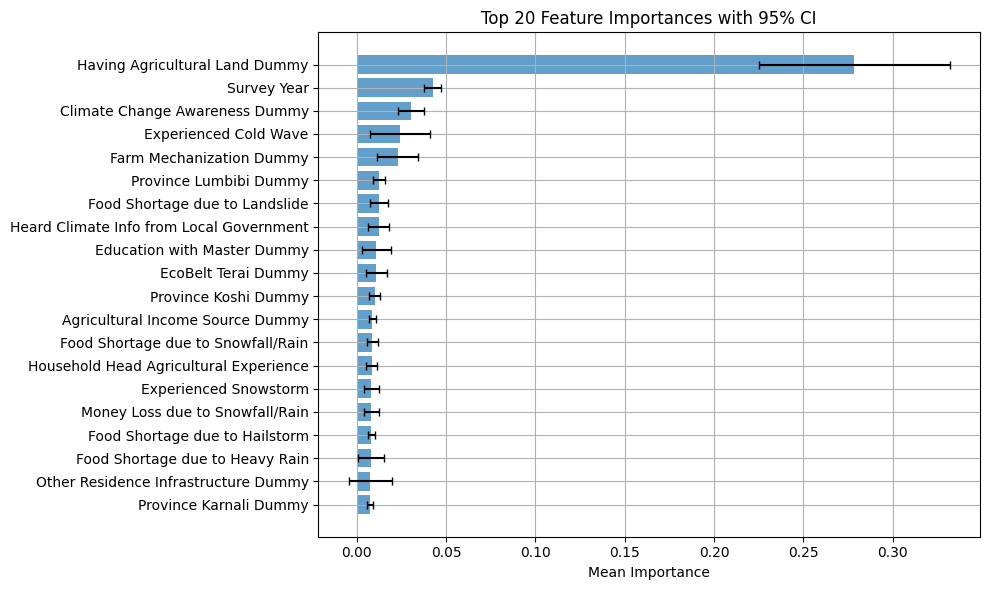

In [ ]:
top20 = import_df.sort_values("Mean_Importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(
    top20.index, 
    top20["Mean_Importance"], 
    xerr=top20["Std_Importance"] * 1.96, 
    align="center", 
    alpha=0.7, 
    ecolor="black", 
    capsize=3
)
plt.xlabel("Mean Importance")
plt.title("Top 20 Feature Importances with 95% CI")
plt.grid()
plt.gca().invert_yaxis()  # largest on top
plt.tight_layout()
plt.show()

In [ ]:
top20.index

Index(['Having Agricultural Land Dummy', 'Survey Year',
       'Climate Change Awareness Dummy', 'Experienced Cold Wave',
       'Farm Mechanization Dummy', 'Province Lumbibi Dummy',
       'Food Shortage due to Landslide',
       'Heard Climate Info from Local Government',
       'Education with Master Dummy', 'EcoBelt Terai Dummy',
       'Province Koshi Dummy', 'Agricultural Income Source Dummy',
       'Food Shortage due to Snowfall/Rain',
       'Household Head Agricultural Experience', 'Experienced Snowstorm',
       'Money Loss due to Snowfall/Rain', 'Food Shortage due to Hailstorm',
       'Food Shortage due to Heavy Rain',
       'Other Residence Infrastructure Dummy', 'Province Karnali Dummy'],
      dtype='object')

## Checking "CommunityPartipationPast25"

### Dataset building

In [ ]:
print(df_all.columns.tolist())

In [ ]:
df_inuse = df_all[[# target and features
                    'CommunityPartipationPast25',
                    
                    # fearures
                    'ClimateChanged_Dummy', 'HeardClimate_Dummy', 
                   'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 
                   'Edu_Bachelor', 'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 
                   'Prov_Bagmati', 'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
                   'Prov_Gandaki', 'Prov_Karnali', # location     
                   'ResidenceOwn_dummy', 'ResidenceRent_dummy', 'ResidenceInstitu_dummy', 'ResidenceOthers_dummy',
                   'ResidInfraPerman_dummy', 'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy', 'ResidInfraOthers_dummy', # house
                    'Remittance_dummy', 
                   'Have_AgriLand', 'HouseHead_AgriExpYear',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 
                   'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 
                   'FramMechan',
                    'IncomeResAgri_dummy', 'IncomeResWage_dummy', 'IncomeResNonAgriBusi_dummy', 'IncomeResRemit_dummy',
                   'IncomeResOthers_dummy', 
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome',
                   'Year',
                   
                   # Awareness sources
                   'ClimateInfo_Radio', 'ClimateInfo_Telev', 'ClimateInfo_News ', 
                   'ClimateInfo_Aware', 'ClimateInfo_Local', 'ClimateInfo_Neigh', 
                   'ClimateInfo_Famil', 'ClimateInfo_Other',
                   
                   # Disaster experiences
                   'ExpDummyDR', 'ExpDummyFF', 'ExpDummyFS', 'ExpDummyFL', 'ExpDummyIN', 'ExpDummyWS', 
                   'ExpDummyTS', 'ExpDummyHS', 'ExpDummyHR', 'ExpDummySR', 'ExpDummySE', 'ExpDummyLS', 
                   'ExpDummySS', 'ExpDummyAV', 'ExpDummyGLOF', 'ExpDummyHW', 'ExpDummyCW', 'ExpDummyDI', 
                   'ExpDummyOT',
                   
                   # DisasterFoodShortage
                   'DisasterFoodShortage_DummyDR', 'DisasterFoodShortage_DummyFF', 'DisasterFoodShortage_DummyFS', 
                   'DisasterFoodShortage_DummyFL', 'DisasterFoodShortage_DummyIN', 'DisasterFoodShortage_DummyWS', 
                   'DisasterFoodShortage_DummyTS', 'DisasterFoodShortage_DummyHS', 'DisasterFoodShortage_DummyHR', 
                   'DisasterFoodShortage_DummySR', 'DisasterFoodShortage_DummySE', 'DisasterFoodShortage_DummyLS', 
                   'DisasterFoodShortage_DummySS', 'DisasterFoodShortage_DummyAV', 'DisasterFoodShortage_DummyGLOF', 
                   'DisasterFoodShortage_DummyHW', 'DisasterFoodShortage_DummyCW', 'DisasterFoodShortage_DummyDI', 
                   'DisasterFoodShortage_DummyOT', 'DisasterDie_DummyDR', 
                   
                   # DisasterDie
                   'DisasterDie_DummyFF', 'DisasterDie_DummyFS', 'DisasterDie_DummyFL', 'DisasterDie_DummyIN', 
                   'DisasterDie_DummyWS', 'DisasterDie_DummyTS', 'DisasterDie_DummyHS', 'DisasterDie_DummyHR', 
                   'DisasterDie_DummySR', 'DisasterDie_DummySE', 'DisasterDie_DummyLS', 'DisasterDie_DummySS', 
                   'DisasterDie_DummyAV', 'DisasterDie_DummyGLOF', 'DisasterDie_DummyHW', 'DisasterDie_DummyCW', 
                   'DisasterDie_DummyDI', 'DisasterDie_DummyOT', 
                   
                   # DisasterMoneyLoss
                   'DisasterMoneyLoss_DummyDR', 'DisasterMoneyLoss_DummyFF', 'DisasterMoneyLoss_DummyFS', 
                   'DisasterMoneyLoss_DummyFL', 'DisasterMoneyLoss_DummyIN', 'DisasterMoneyLoss_DummyWS', 
                   'DisasterMoneyLoss_DummyTS', 'DisasterMoneyLoss_DummyHS', 'DisasterMoneyLoss_DummyHR', 
                   'DisasterMoneyLoss_DummySR', 'DisasterMoneyLoss_DummySE', 'DisasterMoneyLoss_DummyLS', 
                   'DisasterMoneyLoss_DummySS', 'DisasterMoneyLoss_DummyAV', 'DisasterMoneyLoss_DummyGLOF',
                   'DisasterMoneyLoss_DummyHW', 'DisasterMoneyLoss_DummyCW', 'DisasterMoneyLoss_DummyDI', 
                   'DisasterMoneyLoss_DummyOT'
]]

In [ ]:
variname_readable = {'ClimateChanged_Dummy':'Climate Change Awareness Dummy',
                     'HeardClimate_Dummy':'Heard about Climate Change Dummy', 'Respon_Female':'Female Dummy', 
                     'Respon_Age':'Age', 'LivingYear':'Years Living in Community', 'Edu_UnderSLC':'Education under Secondary Certificate Dummy', 
                     'Edu_Certificate':'Education with Secondary Certificate Dummy', 'Edu_Bachelor':'Education with Bachelor Dummy', 
                     'Edu_Master':'Education with Master Dummy',  'Edu_PhD':'Education with PhD Dummy', 
                     'Edu_Literal':'Literate Education Dummy',  'Edu_Illiterate':'Illiterate Dummy', 'Edu_year':'Education Year',
                     'Female_Ratio':'Female Ratio in Household', 'U18_Ratio':'Member Under 18 Ratio', 'A65_Ratio':'Seniors Ratio',
                     'Edu12_Ratio':"Member with 12-Year Education or above Ratio", "Literal_Ratio": "Literate Member Ratio",
                     'EcoBelt_Hill': "EcoBelt Hill Dummy", 'EcoBelt_Mountain': "EcoBelt Mountain Dummy", 'EcoBelt_Terai': "EcoBelt Terai Dummy",
                     'Prov_Bagmati': "Province Bagmati Dummy", 'Prov_Koshi': "Province Koshi Dummy", 'Prov_Lumbini': "Province Lumbibi Dummy",
                     'Prov_Madhesh': "Province Madhesh Dummy", 'Prov_Sudurpaschim': "Province Sudurpaschim Dummy", 'Prov_Gandaki': "Province Gandaki Dummy",
                     'Prov_Karnali': "Province Karnali Dummy",
                     'ResidenceOwn_dummy': "Owned Residence Ownership Dummy", 'ResidenceRent_dummy': 'Rented Residence Ownership Dummy', 
                     'ResidenceInstitu_dummy': 'Institutional Residence Ownership Dummy', 'ResidenceOthers_dummy': 'Other-type Residence Ownership Dummy',
                     'ResidInfraPerman_dummy': 'Permanent Residence Dummy', 'ResidInfraSemi_dummy': 'Semi-Permanent Residence Dummy', 
                     'ResidInfraKachchi_dummy': "Kachchi Residence Dummy", 'ResidInfraOthers_dummy': 'Other Residence Infrastructure Dummy', # house
                     'Remittance_dummy' : "Have Remittance",
                     'Have_AgriLand': "Having Agricultural Land Dummy", 'HouseHead_AgriExpYear': "Household Head Agricultural Experience",
                     'Radio_dummy': "Having Radio Dummy", 'TV_dummy': "Having TV Dummy", 'PC_dummy': "Having Computer Dummy", 'Net_dummy': "Having Internet Dummy",
                     'Phone_dummy': "Having Telephone Dummy", 'Mobile_dummy': "Having Mobile Dummy", 'Motorbike_dummy': "Having Motorbike Dummy", 
                     'Car_dummy': "Having Car Dummy", 'Bike_dummy': "Having Bike Dummy", 'OtherVehi_dummy': "Having Other Vehicle Dummy", 
                     'Refrige_dummy':"Having Refrigator Dummy",
                     'SavingMembership': "Saving Membership Dummy", 'RegularSaving': 'Having Regular Saving Dummy', 
                     'OrgMembership': 'Having Organization Membership Dummy', 'AgriSupport':'Agricultural Supporting Dummy', 
                     'Dist_Road': 'Distance to Motorable Road', 'Dist_HealthCenter': "Distance to Health Center", 
                     'Dist_SecondarySchool': "Distance to Secondary School", 'Dist_Market':"Distance to Market", 'Dist_AgriSupport': 'Distance to Agricultural Center', 
                     'FramMechan':'Farm Mechanization Dummy',
                     'IncomeResAgri_dummy': "Agricultural Income Source Dummy", 'IncomeResWage_dummy': "Wage Income Source Dummy",
                     'IncomeResNonAgriBusi_dummy': "Non-Agricultural Business Income Source Dummy", 'IncomeResRemit_dummy': "Remittance Income Dummy",
                     'IncomeResOthers_dummy': "Others Income Source Dummy", 
                     'CropIncome': "Crop Income", 'LivestockIncome': "Livestock Income", 'NonAgriIncome': "Non-agricultural Income", 
                     'BusiIncome': "Business Income", 'TotalIncome': "Total Income",
                     'Year': "Survey Year",
                                         
                    }

In [ ]:
# ...existing code...
variname_readable.update({
    # Awareness sources
    'ClimateInfo_Radio': "Heard Climate Info from Radio",
    'ClimateInfo_Telev': "Heard Climate Info from Television",
    'ClimateInfo_News ': "Heard Climate Info from Newspaper",
    'ClimateInfo_Aware': "Heard Climate Info from Awareness Program",
    'ClimateInfo_Local': "Heard Climate Info from Local Government",
    'ClimateInfo_Neigh': "Heard Climate Info from Neighbors",
    'ClimateInfo_Famil': "Heard Climate Info from Family",
    'ClimateInfo_Other': "Heard Climate Info from Other Sources",

    # Disaster experiences
    'ExpDummyDR': "Experienced Drought",
    'ExpDummyFF': "Experienced Flash Flood",
    'ExpDummyFS': "Experienced Forest Fire",
    'ExpDummyFL': "Experienced Flood",
    'ExpDummyIN': "Experienced Insect Infestation",
    'ExpDummyWS': "Experienced Windstorm",
    'ExpDummyTS': "Experienced Thunderstorm",
    'ExpDummyHS': "Experienced Hailstorm",
    'ExpDummyHR': "Experienced Heavy Rain",
    'ExpDummySR': "Experienced Snowfall/Rain",
    'ExpDummySE': "Experienced Earthquake",
    'ExpDummyLS': "Experienced Landslide",
    'ExpDummySS': "Experienced Snowstorm",
    'ExpDummyAV': "Experienced Avalanche",
    'ExpDummyGLOF': "Experienced Glacial Lake Outburst Flood",
    'ExpDummyHW': "Experienced Heat Wave",
    'ExpDummyCW': "Experienced Cold Wave",
    'ExpDummyDI': "Experienced Disease Outbreak",
    'ExpDummyOT': "Experienced Other Disaster",

    # Disaster Food Shortage
    'DisasterFoodShortage_DummyDR': "Food Shortage due to Drought",
    'DisasterFoodShortage_DummyFF': "Food Shortage due to Flash Flood",
    'DisasterFoodShortage_DummyFS': "Food Shortage due to Forest Fire",
    'DisasterFoodShortage_DummyFL': "Food Shortage due to Flood",
    'DisasterFoodShortage_DummyIN': "Food Shortage due to Insect Infestation",
    'DisasterFoodShortage_DummyWS': "Food Shortage due to Windstorm",
    'DisasterFoodShortage_DummyTS': "Food Shortage due to Thunderstorm",
    'DisasterFoodShortage_DummyHS': "Food Shortage due to Hailstorm",
    'DisasterFoodShortage_DummyHR': "Food Shortage due to Heavy Rain",
    'DisasterFoodShortage_DummySR': "Food Shortage due to Snowfall/Rain",
    'DisasterFoodShortage_DummySE': "Food Shortage due to Earthquake",
    'DisasterFoodShortage_DummyLS': "Food Shortage due to Landslide",
    'DisasterFoodShortage_DummySS': "Food Shortage due to Snowstorm",
    'DisasterFoodShortage_DummyAV': "Food Shortage due to Avalanche",
    'DisasterFoodShortage_DummyGLOF': "Food Shortage due to GLOF",
    'DisasterFoodShortage_DummyHW': "Food Shortage due to Heat Wave",
    'DisasterFoodShortage_DummyCW': "Food Shortage due to Cold Wave",
    'DisasterFoodShortage_DummyDI': "Food Shortage due to Disease Outbreak",
    'DisasterFoodShortage_DummyOT': "Food Shortage due to Other Disaster",
    'DisasterDie_DummyDR': "Death due to Drought",

    # Disaster Die
    'DisasterDie_DummyFF': "Death due to Flash Flood",
    'DisasterDie_DummyFS': "Death due to Forest Fire",
    'DisasterDie_DummyFL': "Death due to Flood",
    'DisasterDie_DummyIN': "Death due to Insect Infestation",
    'DisasterDie_DummyWS': "Death due to Windstorm",
    'DisasterDie_DummyTS': "Death due to Thunderstorm",
    'DisasterDie_DummyHS': "Death due to Hailstorm",
    'DisasterDie_DummyHR': "Death due to Heavy Rain",
    'DisasterDie_DummySR': "Death due to Snowfall/Rain",
    'DisasterDie_DummySE': "Death due to Earthquake",
    'DisasterDie_DummyLS': "Death due to Landslide",
    'DisasterDie_DummySS': "Death due to Snowstorm",
    'DisasterDie_DummyAV': "Death due to Avalanche",
    'DisasterDie_DummyGLOF': "Death due to GLOF",
    'DisasterDie_DummyHW': "Death due to Heat Wave",
    'DisasterDie_DummyCW': "Death due to Cold Wave",
    'DisasterDie_DummyDI': "Death due to Disease Outbreak",
    'DisasterDie_DummyOT': "Death due to Other Disaster",

    # Disaster Money Loss
    'DisasterMoneyLoss_DummyDR': "Money Loss due to Drought",
    'DisasterMoneyLoss_DummyFF': "Money Loss due to Flash Flood",
    'DisasterMoneyLoss_DummyFS': "Money Loss due to Forest Fire",
    'DisasterMoneyLoss_DummyFL': "Money Loss due to Flood",
    'DisasterMoneyLoss_DummyIN': "Money Loss due to Insect Infestation",
    'DisasterMoneyLoss_DummyWS': "Money Loss due to Windstorm",
    'DisasterMoneyLoss_DummyTS': "Money Loss due to Thunderstorm",
    'DisasterMoneyLoss_DummyHS': "Money Loss due to Hailstorm",
    'DisasterMoneyLoss_DummyHR': "Money Loss due to Heavy Rain",
    'DisasterMoneyLoss_DummySR': "Money Loss due to Snowfall/Rain",
    'DisasterMoneyLoss_DummySE': "Money Loss due to Earthquake",
    'DisasterMoneyLoss_DummyLS': "Money Loss due to Landslide",
    'DisasterMoneyLoss_DummySS': "Money Loss due to Snowstorm",
    'DisasterMoneyLoss_DummyAV': "Money Loss due to Avalanche",
    'DisasterMoneyLoss_DummyGLOF': "Money Loss due to GLOF",
    'DisasterMoneyLoss_DummyHW': "Money Loss due to Heat Wave",
    'DisasterMoneyLoss_DummyCW': "Money Loss due to Cold Wave",
    'DisasterMoneyLoss_DummyDI': "Money Loss due to Disease Outbreak",
    'DisasterMoneyLoss_DummyOT': "Money Loss due to Other Disaster",
})
# ...existing code...

In [ ]:
variname_readable.update({'CommunityPartipationPast25': 'Participation in Community-based Natural Resource Management Activities in the Past Dummy'})

In [ ]:
data_summary = df_inuse.describe().T

In [ ]:
data_summary.index = data_summary.index.map(variname_readable)

In [ ]:
data_summary.to_excel("MLD01e_Results/Table03_DataSummaryAction_CommunityPartipationPast25.xlsx")

In [ ]:
data_summary

In [ ]:
df_inuse.columns = df_inuse.columns.map(variname_readable)

### Hyper Tunining

In [ ]:
y = df_inuse['Participation in Community-based Natural Resource Management Activities in the Past Dummy'].astype(int)
X = df_inuse.drop(columns=['Participation in Community-based Natural Resource Management Activities in the Past Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [ ]:
clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    device = 'cuda'
)

In [ ]:
param_distributions = {
    'n_estimators': [200, 500, 1_000, 2_000],
    'max_depth': [4,  8, 16],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 5, 10]
}

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=200,                 # increase for a more exhaustive search if you have time
    scoring='accuracy',
    return_train_score=True,
    cv=cv,
    verbose=3,
    refit=True,                # refit on entire data with best params
    random_state=42
)

search.fit(X, y)

In [ ]:
# 7) Results
print("Best mean CV accuracy:", f"{search.best_score_:.4f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

In [ ]:
cvres = pd.DataFrame(search.cv_results_)

In [ ]:
cvres.to_parquet('MLD01e_Results/MLD01e_C03_ActionFactorInvestigation_CommunityPartipationPast25.parquet')

In [ ]:
cols = ['mean_test_score', 'std_test_score', 'rank_test_score'] + [c for c in cvres.columns if c.startswith('param_')]
cvres_sorted = cvres.sort_values('rank_test_score')[cols].head(10)

In [ ]:
cvres_sorted

### 10-fold 10-epoch Estimation

In [126]:
y = df_inuse['Participation in Community-based Natural Resource Management Activities in the Past Dummy'].astype(int)
X = df_inuse.drop(columns=['Participation in Community-based Natural Resource Management Activities in the Past Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [127]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [128]:
def Metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

    return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]

In [129]:
prob_matrix = np.zeros([X.shape[0], 10])

In [130]:
acc_lines = []
importances_df = []
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for random_seed in range(42, 42*11, 42):
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=1000, max_depth=16,
            learning_rate=0.05, subsample=0.9,
            colsample_bytree=1.0, min_child_weight=1, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)


        metrics = Metrics(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred).flatten()
        line  = [fold, random_seed] + metrics + list(cm)
        importances = clf.feature_importances_

        acc_lines.append(line)
        importances_df.append(importances)
        
    

fold: 1, random_seed:42
Accuracy: 0.8444252376836646
Precision: 0.7239819004524887
Recall   : 0.5734767025089605
F1-score : 0.64
fold: 1, random_seed:84
Accuracy: 0.8547968885047537
Precision: 0.751131221719457
Recall   : 0.5949820788530465
F1-score : 0.664
fold: 1, random_seed:126
Accuracy: 0.8487467588591184
Precision: 0.7407407407407407
Recall   : 0.5734767025089605
F1-score : 0.6464646464646465
fold: 1, random_seed:168
Accuracy: 0.8409680207433017
Precision: 0.7111111111111111
Recall   : 0.5734767025089605
F1-score : 0.6349206349206349
fold: 1, random_seed:210
Accuracy: 0.8539325842696629
Precision: 0.7477477477477478
Recall   : 0.5949820788530465
F1-score : 0.6626746506986028
fold: 1, random_seed:252
Accuracy: 0.8522039757994814
Precision: 0.7432432432432432
Recall   : 0.5913978494623656
F1-score : 0.6586826347305389
fold: 1, random_seed:294
Accuracy: 0.8513396715643907
Precision: 0.7377777777777778
Recall   : 0.5949820788530465
F1-score : 0.6587301587301587
fold: 1, random_seed:3

KeyboardInterrupt: 

In [ ]:
acc_df = pd.DataFrame(acc_lines)

In [ ]:
acc_df.columns = ['fold', 'random_seed', 'acc', 'prec', 'recall', 'f1', 'TN', 'FP', 'FN', 'TP']

In [ ]:
acc_df.to_excel('MLD01e_Results/Table_C03_AccuracyTableAction_CommunityPartipationPast25.xlsx')


In [ ]:
acc_df[['acc', 'prec', 'recall', 'f1']].mean(axis=0)

acc       0.863001
prec      0.703028
recall    0.605461
f1        0.650198
dtype: float64

In [ ]:
import_df = pd.DataFrame(importances_df).T

In [ ]:
import_df.index = X.columns

In [ ]:
import_df['Mean_Importance'] = import_df.iloc[:,:100].mean(axis = 1)
import_df['Std_Importance'] = import_df.iloc[:,:100].std(axis = 1)

In [ ]:
import_df['Mean_Importance'] 

Climate Change Awareness Dummy           0.004997
Heard about Climate Change Dummy         0.008319
Female Dummy                             0.004117
Age                                      0.003195
Years Living in Community                0.003388
                                           ...   
Money Loss due to Heat Wave              0.000091
Money Loss due to Cold Wave              0.006310
Money Loss due to Disease Outbreak       0.004127
Money Loss due to Other Disaster         0.000136
Total Money Loss (NRs) due to Drought    0.003907
Name: Mean_Importance, Length: 156, dtype: float32

In [ ]:
# Get importance values
importances = pd.Series(import_df['Mean_Importance'] , index=import_df.index)

# Sort descending
importances = importances.sort_values(ascending=False)

print(importances.head(20))   # Top 20 important features

Survey Year                                 0.141159
Having Agricultural Land Dummy              0.074941
Province Koshi Dummy                        0.044982
Farm Mechanization Dummy                    0.024447
Experienced Earthquake                      0.021269
Heard Climate Info from Other Sources       0.016808
Food Shortage due to Flash Flood            0.015556
Food Shortage due to Disease Outbreak       0.015095
Other-type Residence Ownership Dummy        0.014033
Death due to Cold Wave                      0.013907
Province Bagmati Dummy                      0.012964
Province Gandaki Dummy                      0.011746
Food Shortage due to Forest Fire            0.011138
Death due to Disease Outbreak               0.010698
Money Loss due to Insect Infestation        0.010308
Death due to Heat Wave                      0.010086
Province Sudurpaschim Dummy                 0.010072
Experienced Flash Flood                     0.010044
Education with Master Dummy                 0.

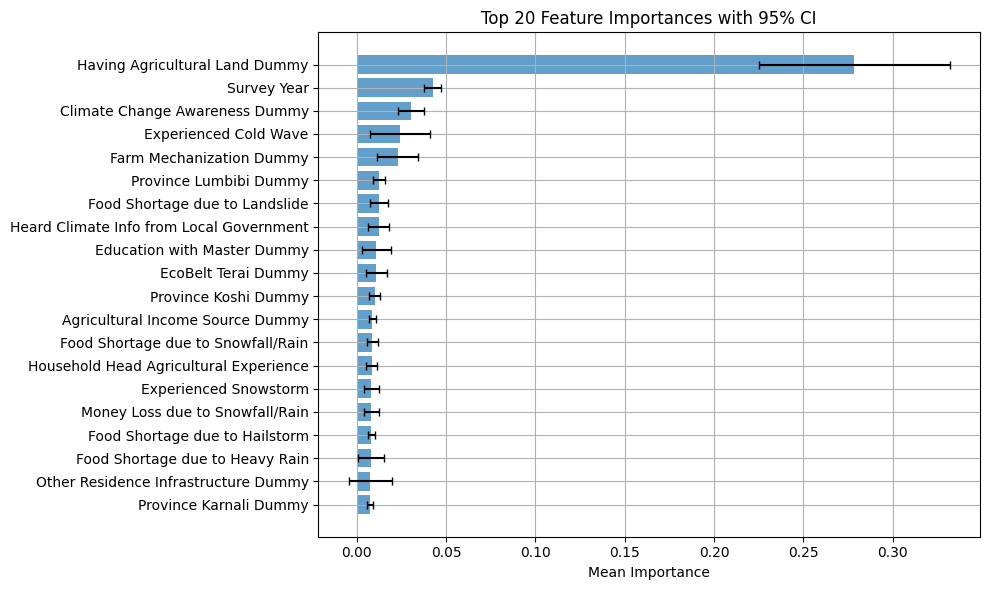

In [ ]:
top20 = import_df.sort_values("Mean_Importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(
    top20.index, 
    top20["Mean_Importance"], 
    xerr=top20["Std_Importance"] * 1.96, 
    align="center", 
    alpha=0.7, 
    ecolor="black", 
    capsize=3
)
plt.xlabel("Mean Importance")
plt.title("Top 20 Feature Importances with 95% CI")
plt.grid()
plt.gca().invert_yaxis()  # largest on top
plt.tight_layout()
plt.show()

In [ ]:
top20.index

Index(['Having Agricultural Land Dummy', 'Survey Year',
       'Climate Change Awareness Dummy', 'Experienced Cold Wave',
       'Farm Mechanization Dummy', 'Province Lumbibi Dummy',
       'Food Shortage due to Landslide',
       'Heard Climate Info from Local Government',
       'Education with Master Dummy', 'EcoBelt Terai Dummy',
       'Province Koshi Dummy', 'Agricultural Income Source Dummy',
       'Food Shortage due to Snowfall/Rain',
       'Household Head Agricultural Experience', 'Experienced Snowstorm',
       'Money Loss due to Snowfall/Rain', 'Food Shortage due to Hailstorm',
       'Food Shortage due to Heavy Rain',
       'Other Residence Infrastructure Dummy', 'Province Karnali Dummy'],
      dtype='object')